# Verify TP6→TP24 Initial & Boundary Conditions

Loads big-endian float32 binary files generated by `TP6toTP24_3d_TeleZ_138lev.m`  
and produces diagnostic plots (surface maps, depth sections, Hovmöllers) and statistics.

Files are expected in **`SETUP_DIR`** below — missing files are skipped gracefully.

In [1]:
import os, re, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=RuntimeWarning)   # suppress numpy/matplotlib noise
warnings.filterwarnings('always', category=UserWarning)      # always show missing-file warnings
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## Configuration

In [2]:
# Directory containing the generated .bin files
SETUP_DIR  = '/data/SO3/edavenport/tpose24/setup'

# Path to input/data (for parsing delR)
DATA_FILE  = os.path.join(os.getcwd(), 'input', 'data')

# Grid dimensions (from SIZE.h and input/data)
NX, NY, NZ = 512, 384, 138
XGORIG = 209.3333   # western edge of cell (1,1), degrees E
YGORIG = -5.5       # southern edge of cell (1,1), degrees N
DX = DY = 1.0 / 24.0

# OBC parameters
NOBCS   = 8
NTIME   = 122       # records from iter 72:72:8784
DELTA_T = 300.0     # model time step (s)
DT_ITER = 72        # output cadence (model time steps)

# Output directory for saved figures
OUTDIR = os.path.join(os.getcwd(), 'verification')
os.makedirs(OUTDIR, exist_ok=True)

print(f'Setup dir : {SETUP_DIR}')
print(f'Data file : {DATA_FILE} (exists={os.path.isfile(DATA_FILE)})')
print(f'Output dir: {OUTDIR}')

Setup dir : /data/SO3/edavenport/tpose24/setup
Data file : /home/edavenport/analysis/tpose24-138lev/input/data (exists=True)
Output dir: /home/edavenport/analysis/tpose24-138lev/verification


## Grid

In [3]:
def parse_delR(fname, nz):
    """Extract the first nz delR values from the uncommented delR entry in MITgcm data namelist.
    MITgcm reads exactly Nr values and ignores any surplus entries."""
    with open(fname) as fh:
        lines = fh.readlines()
    # Drop comment lines so the old commented-out delR block is ignored
    text = ''.join(l for l in lines if not l.lstrip().startswith('#'))
    m = re.search(r'\bdelR\s*=\s*(.*?)(?=\n\s*\w+\s*=|\n\s*/)', text, re.DOTALL)
    if not m:
        raise RuntimeError(f'delR not found in {fname}')
    nums = re.findall(r'[\d]+\.[\d]*', m.group(1))
    parsed = np.array([float(v) for v in nums])
    if len(parsed) < nz:
        raise RuntimeError(f'delR: only {len(parsed)} values found, need {nz}')
    if len(parsed) > nz:
        warnings.warn(
            f'delR has {len(parsed)} entries but Nr={nz}; using first {nz} (matches MITgcm behavior).',
            UserWarning, stacklevel=2)
    return parsed[:nz]

delR = parse_delR(DATA_FILE, NZ)
print(f'Using {len(delR)} delR values')

# Cell-centre depths (positive downward, m)
RC  = np.cumsum(delR) - delR / 2.0

# Cell-centre lon/lat
xc  = XGORIG + (np.arange(NX) + 0.5) * DX   # (NX,)
yc  = YGORIG + (np.arange(NY) + 0.5) * DY   # (NY,)

# OBC time axis (hours)
t_hours = np.arange(1, NTIME + 1) * DT_ITER * DELTA_T / 3600.0

# Key indices
j_eq  = int(np.argmin(np.abs(yc)))     # nearest to equator
i_mid = NX // 2                         # mid-longitude

print(f'xc     : {xc[0]:.3f} – {xc[-1]:.3f} °E')
print(f'yc     : {yc[0]:.3f} – {yc[-1]:.3f} °N')
print(f'RC     : {RC[0]:.2f} – {RC[-1]:.1f} m  ({NZ} levels)')
print(f'Equator: j={j_eq}, yc={yc[j_eq]:.3f} °N')
print(f'Mid-lon: i={i_mid}, xc={xc[i_mid]:.3f} °E')
print(f'OBC t  : {t_hours[0]:.1f} – {t_hours[-1]:.1f} h  ({NTIME} records)')

Using 138 delR values
xc     : 209.354 – 230.646 °E
yc     : -5.479 – 10.479 °N
RC     : 0.50 – 5450.0 m  (138 levels)
Equator: j=132, yc=0.021 °N
Mid-lon: i=256, xc=220.021 °E
OBC t  : 6.0 – 732.0 h  (122 records)


/tmp/ipykernel_2167111/1537962917.py:21: UserWarning: delR has 144 entries but Nr=138; using first 138 (matches MITgcm behavior).
  delR = parse_delR(DATA_FILE, NZ)


## Helper functions

In [4]:
# ── I/O ───────────────────────────────────────────────────────────────────────

def file_ok(path):
    if not os.path.isfile(path):
        warnings.warn(f'Expected file not found: {path}', UserWarning, stacklevel=2)
        return False
    return True

def load_3d(path):
    """IC 3D: Matlab [NX,NY,NZ] col-major → numpy [NZ,NY,NX]."""
    return np.fromfile(path, dtype='>f4').reshape((NZ, NY, NX))

def load_2d(path):
    """IC 2D: Matlab [NX,NY] col-major → numpy [NY,NX]."""
    return np.fromfile(path, dtype='>f4').reshape((NY, NX))

def load_obc_3d(path, npts):
    """OBC 3D: NTIME × [npts,NZ] col-major → [NTIME,NZ,npts]."""
    return np.fromfile(path, dtype='>f4').reshape((NTIME, NZ, npts))

def load_obc_eta(path, npts):
    """OBC SSH: NTIME × [npts] → [NTIME,npts]."""
    return np.fromfile(path, dtype='>f4').reshape((NTIME, npts))

# ── Plot helpers ──────────────────────────────────────────────────────────────

def cbar(fig, ax, im, label=''):
    cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cb.set_label(label, fontsize=8)
    cb.ax.tick_params(labelsize=7)
    return cb

def mask_land(arr, threshold=0.0):
    """Replace exact zeros with NaN (land mask)."""
    out = arr.astype(float)
    out[out == threshold] = np.nan
    return out

def sym_pct(arr, pct=99):
    """Symmetric color limit from percentile of |arr|."""
    a = arr[np.isfinite(arr)]
    if a.size == 0:
        return -1, 1
    v = np.percentile(np.abs(a), pct)
    return -v, v

def pct_range(arr, lo=2, hi=98):
    a = arr[np.isfinite(arr)]
    if a.size == 0:
        return None, None
    return np.percentile(a, lo), np.percentile(a, hi)

def map_ax(ax, d2d, title='', cmap='RdBu_r', vmin=None, vmax=None):
    """pcolormesh on lon/lat axes; d2d shape [NY,NX]."""
    im = ax.pcolormesh(xc, yc, d2d, cmap=cmap, vmin=vmin, vmax=vmax,
                       shading='auto', rasterized=True)
    ax.set(title=title, xlabel='Lon (°E)', ylabel='Lat (°N)')
    ax.set_xlim(xc[0], xc[-1]); ax.set_ylim(yc[0], yc[-1])
    return im

def sec_ax(ax, d_zx, x_coord, title='', cmap='RdBu_r',
           vmin=None, vmax=None, xlabel='', zlim=None):
    """pcolormesh depth section; d_zx shape [NZ, npts]."""
    im = ax.pcolormesh(x_coord, RC, d_zx, cmap=cmap, vmin=vmin, vmax=vmax,
                       shading='auto', rasterized=True)
    ax.set(title=title, xlabel=xlabel, ylabel='Depth (m)')
    ax.invert_yaxis()
    if zlim is not None:
        ax.set_ylim(zlim[1], zlim[0])
    return im

print('Helpers defined.')

Helpers defined.


---
# Initial Conditions

## Load IC files

In [5]:
IC_FILES = {
    'Temp' : 'Tini_frmTP6Vel_EMv1te.bin',
    'Salt' : 'Sini_frmTP6Vel_EMv1te.bin',
    'Uvel' : 'Uini_frmTP6Vel_EMv1te.bin',
    'Vvel' : 'Vini_frmTP6Vel_EMv1te.bin',
    'SSH'  : 'ETAini_frmTP6Vel_EMv1.bin',
    'Bathy': 'Bathy_frmTP6_EMv1.bin',
}

ic = {}
for vname, fname in IC_FILES.items():
    path = os.path.join(SETUP_DIR, fname)
    if not file_ok(path):
        continue
    print(f'Loading {fname} ...')
    if vname in ('SSH', 'Bathy'):
        ic[vname] = load_2d(path)
    else:
        ic[vname] = load_3d(path)
    shape = ic[vname].shape
    print(f'  → shape {shape},  dtype {ic[vname].dtype}')

print(f'\nLoaded: {list(ic.keys())}')

Loading Tini_frmTP6Vel_EMv1te.bin ...
  → shape (138, 384, 512),  dtype >f4
Loading Sini_frmTP6Vel_EMv1te.bin ...
  → shape (138, 384, 512),  dtype >f4
Loading Uini_frmTP6Vel_EMv1te.bin ...
  → shape (138, 384, 512),  dtype >f4
Loading Vini_frmTP6Vel_EMv1te.bin ...
  → shape (138, 384, 512),  dtype >f4
Loading ETAini_frmTP6Vel_EMv1.bin ...
  → shape (384, 512),  dtype >f4
Loading Bathy_frmTP6_EMv1.bin ...
  → shape (384, 512),  dtype >f4

Loaded: ['Temp', 'Salt', 'Uvel', 'Vvel', 'SSH', 'Bathy']


## IC Statistics

In [6]:
print(f'{"Variable":8s}  {"min":>10s}  {"max":>10s}  {"mean":>10s}  {"std":>10s}  {"n non-zero":>12s}')
print('-' * 70)
for vname, arr in ic.items():
    a = arr.ravel().astype(float)
    a = a[a != 0.0]
    a = a[np.isfinite(a)]
    if a.size == 0:
        print(f'{vname:8s}  (all zeros or empty)')
        continue
    print(f'{vname:8s}  {a.min():10.4g}  {a.max():10.4g}  '
          f'{a.mean():10.4g}  {a.std():10.4g}  {a.size:12,}')

if 'Uvel' in ic:
    umax = np.abs(ic['Uvel']).max()
    vmax = np.abs(ic['Vvel']).max() if 'Vvel' in ic else float('nan')
    print(f'\nMax |Uvel| = {umax:.4f} m/s')
    print(f'Max |Vvel| = {vmax:.4f} m/s')

Variable         min         max        mean         std    n non-zero
----------------------------------------------------------------------
Temp          -1.287       28.59       13.21       10.36    27,131,904
Salt           30.76       35.78       34.82      0.3155    27,131,904
Uvel           -1.43       1.325      -0.042      0.2869    27,131,904
Vvel          -0.806      0.8543    0.002371     0.09991    27,131,904
SSH          -0.4168      0.1196     -0.1203      0.1121       196,608
Bathy          -5355       -2649       -4624       290.2       196,608

Max |Uvel| = 1.4296 m/s
Max |Vvel| = 0.8543 m/s


## Surface Maps (T, S, U, V)

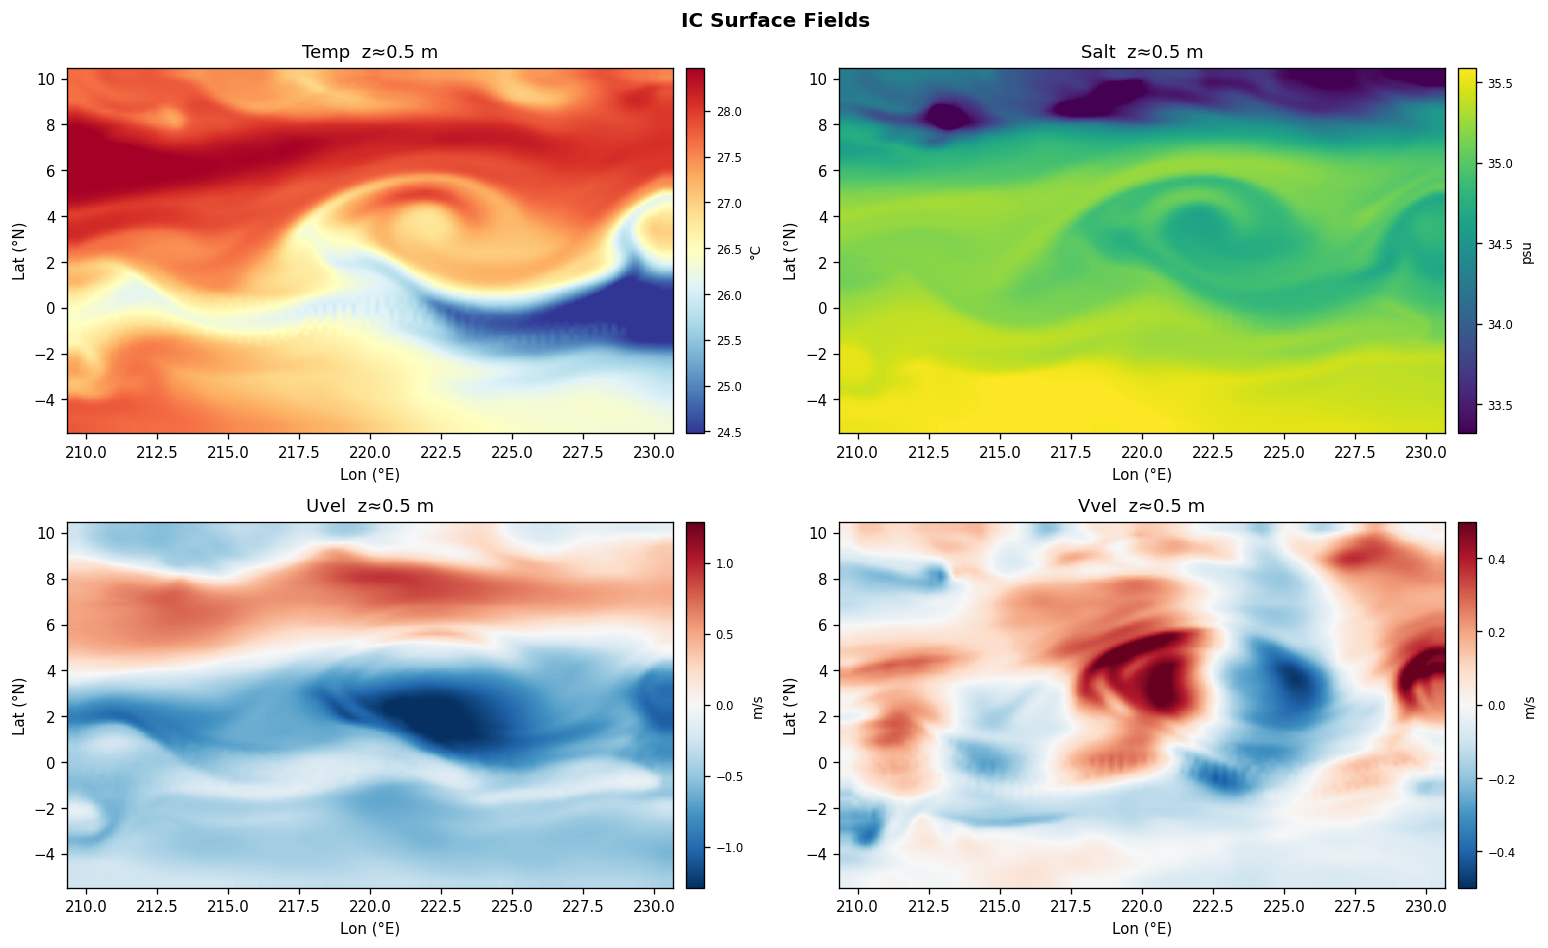

In [7]:
surf_vars = [v for v in ('Temp', 'Salt', 'Uvel', 'Vvel') if v in ic]
cfgs = {
    'Temp': ('RdYlBu_r', '°C',  None),
    'Salt': ('viridis',  'psu', None),
    'Uvel': ('RdBu_r',   'm/s', 'sym'),
    'Vvel': ('RdBu_r',   'm/s', 'sym'),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, vname in zip(axes.ravel(), surf_vars):
    d = mask_land(ic[vname][0, :, :])   # surface [NY, NX]
    cmap, label, mode = cfgs[vname]
    vmin, vmax = sym_pct(d) if mode == 'sym' else pct_range(d)
    im = map_ax(ax, d, title=f'{vname}  z≈{RC[0]:.1f} m', cmap=cmap, vmin=vmin, vmax=vmax)
    cbar(fig, ax, im, label)
for ax in axes.ravel()[len(surf_vars):]:
    ax.set_visible(False)
fig.suptitle('IC Surface Fields', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'ic_surface_maps.png'), dpi=150, bbox_inches='tight')
plt.show()

## Deep Maps (T, S at ~500 m and ~2000 m)

iz500=85 (RC=487.5 m),  iz2000=102 (RC=1950.0 m)


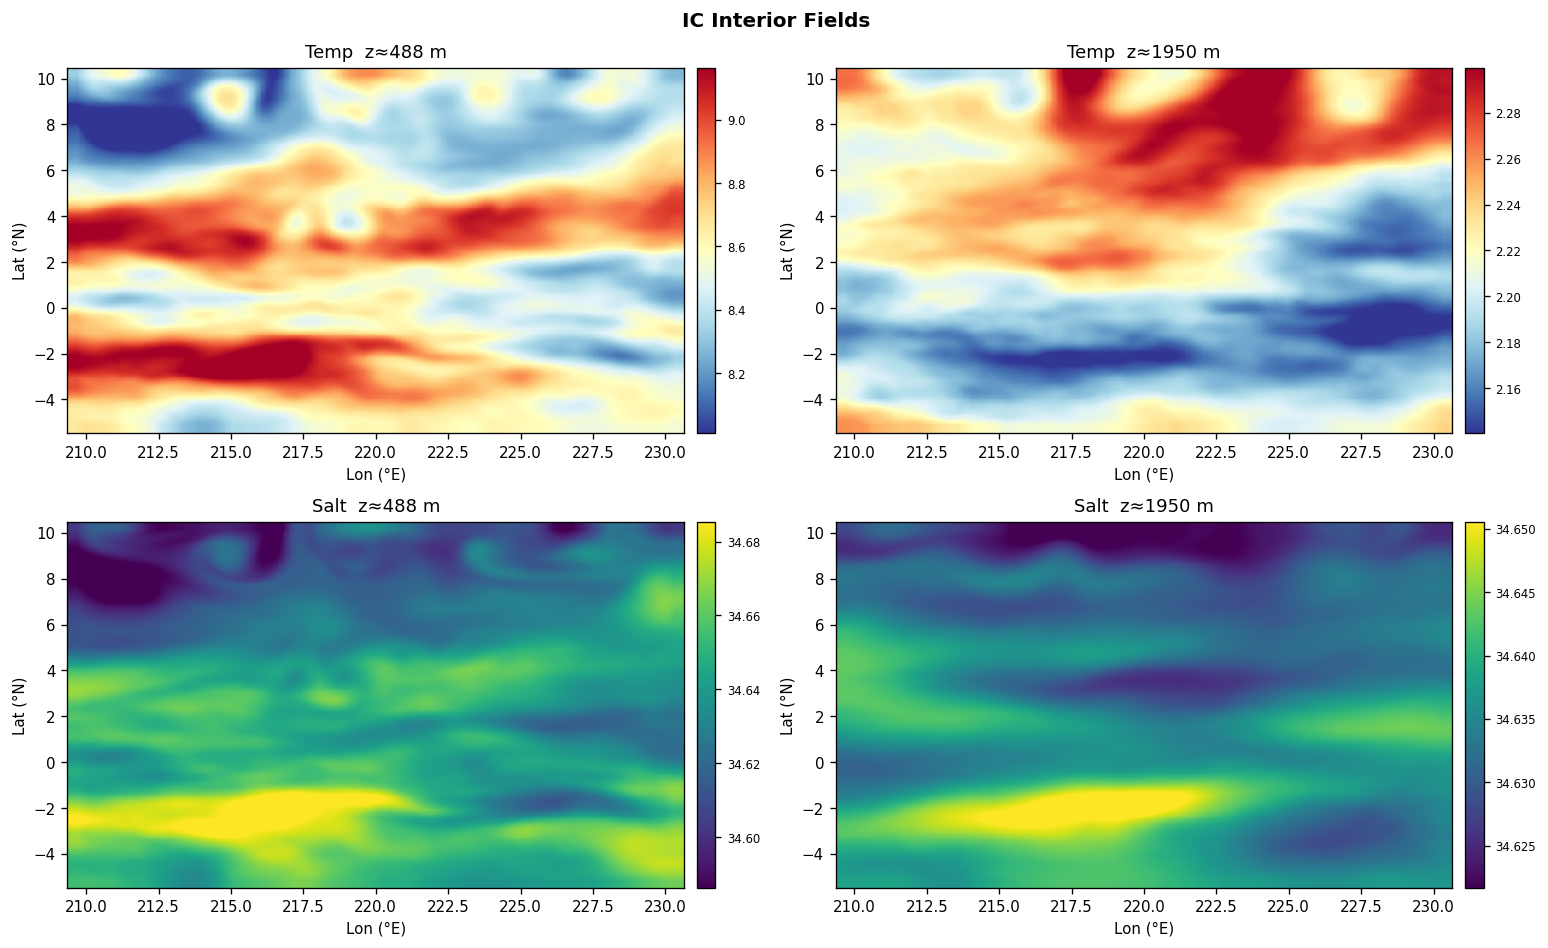

In [8]:
iz500  = int(np.argmin(np.abs(RC - 500)))
iz2000 = int(np.argmin(np.abs(RC - 2000)))
print(f'iz500={iz500} (RC={RC[iz500]:.1f} m),  iz2000={iz2000} (RC={RC[iz2000]:.1f} m)')

panels = [('Temp', iz500, 'RdYlBu_r'), ('Temp', iz2000, 'RdYlBu_r'),
          ('Salt', iz500, 'viridis'),   ('Salt', iz2000, 'viridis')]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (vname, iz, cmap) in zip(axes.ravel(), panels):
    if vname not in ic:
        ax.set_visible(False); continue
    d = mask_land(ic[vname][iz, :, :])
    vmin, vmax = pct_range(d)
    im = map_ax(ax, d, title=f'{vname}  z≈{RC[iz]:.0f} m', cmap=cmap, vmin=vmin, vmax=vmax)
    cbar(fig, ax, im)
fig.suptitle('IC Interior Fields', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'ic_deep_maps.png'), dpi=150, bbox_inches='tight')
plt.show()

## Equatorial Lon–Depth Sections (upper 500 m)

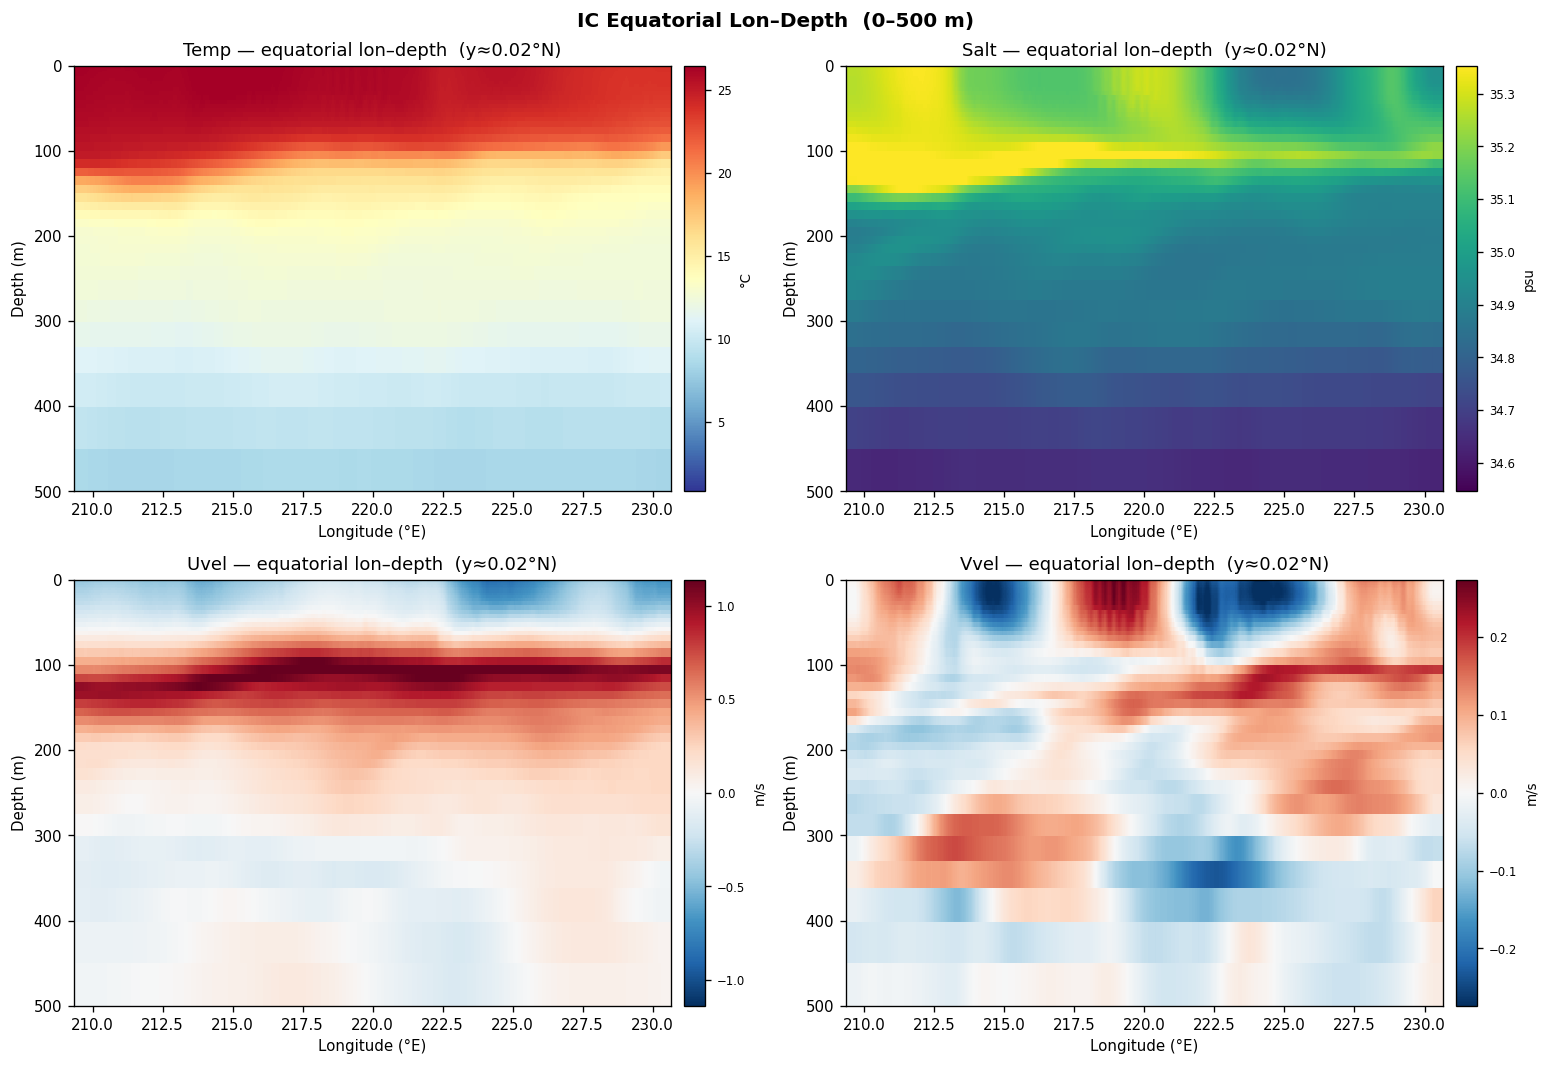

In [9]:
sect_vars = [v for v in ('Temp', 'Salt', 'Uvel', 'Vvel') if v in ic]
cfgs_sec = {'Temp': ('RdYlBu_r','°C'), 'Salt': ('viridis','psu'),
            'Uvel': ('RdBu_r','m/s'),  'Vvel': ('RdBu_r','m/s')}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, vname in zip(axes.ravel(), sect_vars):
    sec = mask_land(ic[vname][:, j_eq, :])   # [NZ, NX]
    cmap, label = cfgs_sec[vname]
    vmin, vmax = sym_pct(sec) if vname in ('Uvel','Vvel') else pct_range(sec)
    im = sec_ax(ax, sec, xc,
                title=f'{vname} — equatorial lon–depth  (y≈{yc[j_eq]:.2f}°N)',
                cmap=cmap, vmin=vmin, vmax=vmax, xlabel='Longitude (°E)', zlim=(0, 500))
    cbar(fig, ax, im, label)
for ax in axes.ravel()[len(sect_vars):]:
    ax.set_visible(False)
fig.suptitle('IC Equatorial Lon–Depth  (0–500 m)', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'ic_eq_londepth_upper.png'), dpi=150, bbox_inches='tight')
plt.show()

## Equatorial Lon–Depth Sections (full depth)

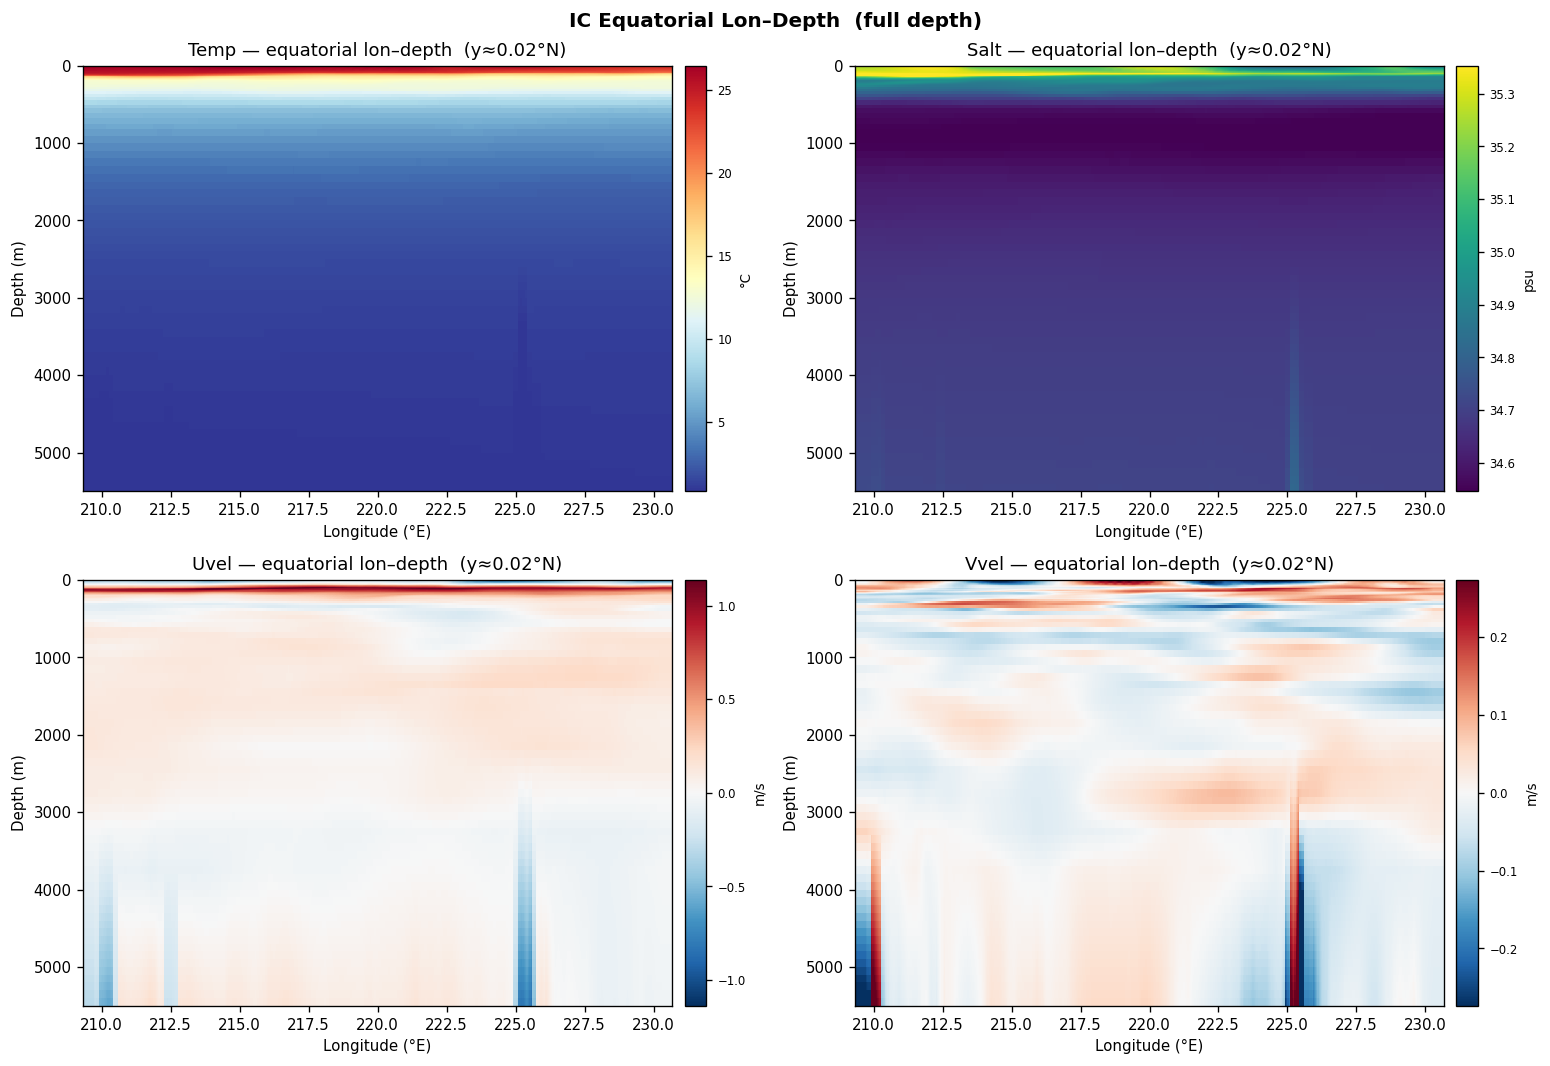

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, vname in zip(axes.ravel(), sect_vars):
    sec = mask_land(ic[vname][:, j_eq, :])   # [NZ, NX]
    cmap, label = cfgs_sec[vname]
    vmin, vmax = sym_pct(sec) if vname in ('Uvel','Vvel') else pct_range(sec)
    im = sec_ax(ax, sec, xc,
                title=f'{vname} — equatorial lon–depth  (y≈{yc[j_eq]:.2f}°N)',
                cmap=cmap, vmin=vmin, vmax=vmax, xlabel='Longitude (°E)')
    cbar(fig, ax, im, label)
for ax in axes.ravel()[len(sect_vars):]:
    ax.set_visible(False)
fig.suptitle('IC Equatorial Lon–Depth  (full depth)', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'ic_eq_londepth_full.png'), dpi=150, bbox_inches='tight')
plt.show()

## Lat–Depth Sections at Mid-Longitude

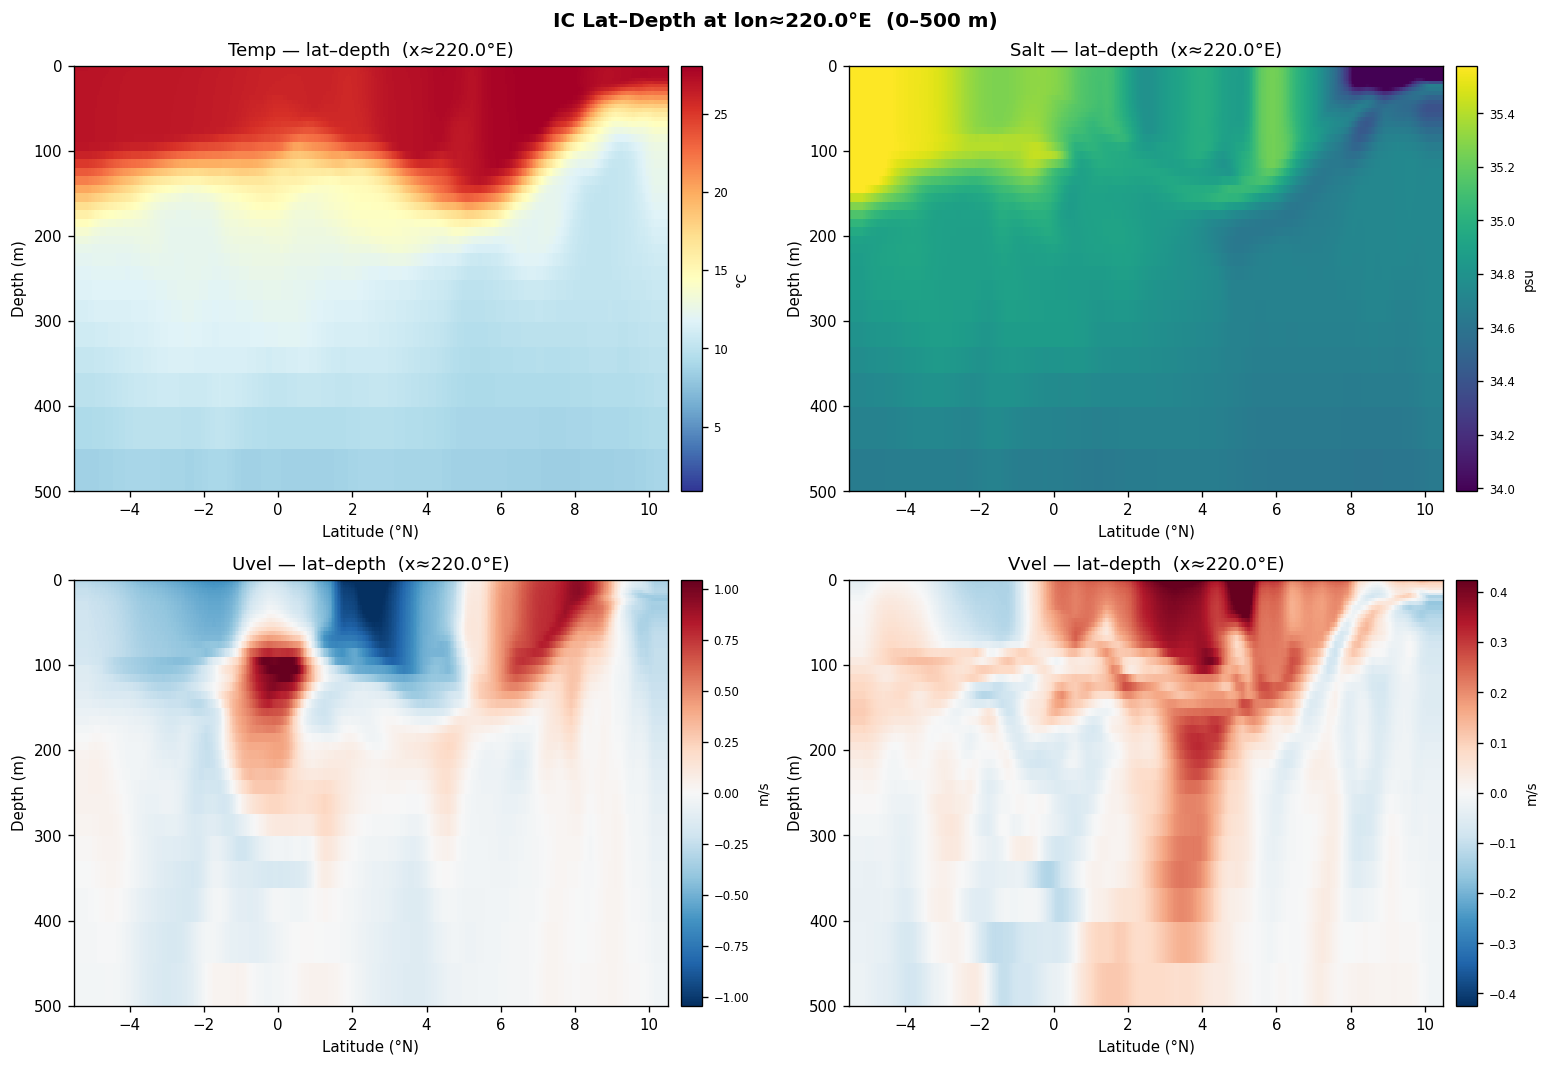

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, vname in zip(axes.ravel(), sect_vars):
    sec = mask_land(ic[vname][:, :, i_mid])   # [NZ, NY]
    cmap, label = cfgs_sec[vname]
    vmin, vmax = sym_pct(sec) if vname in ('Uvel','Vvel') else pct_range(sec)
    im = sec_ax(ax, sec, yc,
                title=f'{vname} — lat–depth  (x≈{xc[i_mid]:.1f}°E)',
                cmap=cmap, vmin=vmin, vmax=vmax, xlabel='Latitude (°N)', zlim=(0, 500))
    cbar(fig, ax, im, label)
for ax in axes.ravel()[len(sect_vars):]:
    ax.set_visible(False)
fig.suptitle(f'IC Lat–Depth at lon≈{xc[i_mid]:.1f}°E  (0–500 m)', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'ic_lat_depth_upper.png'), dpi=150, bbox_inches='tight')
plt.show()

## SSH and Bathymetry

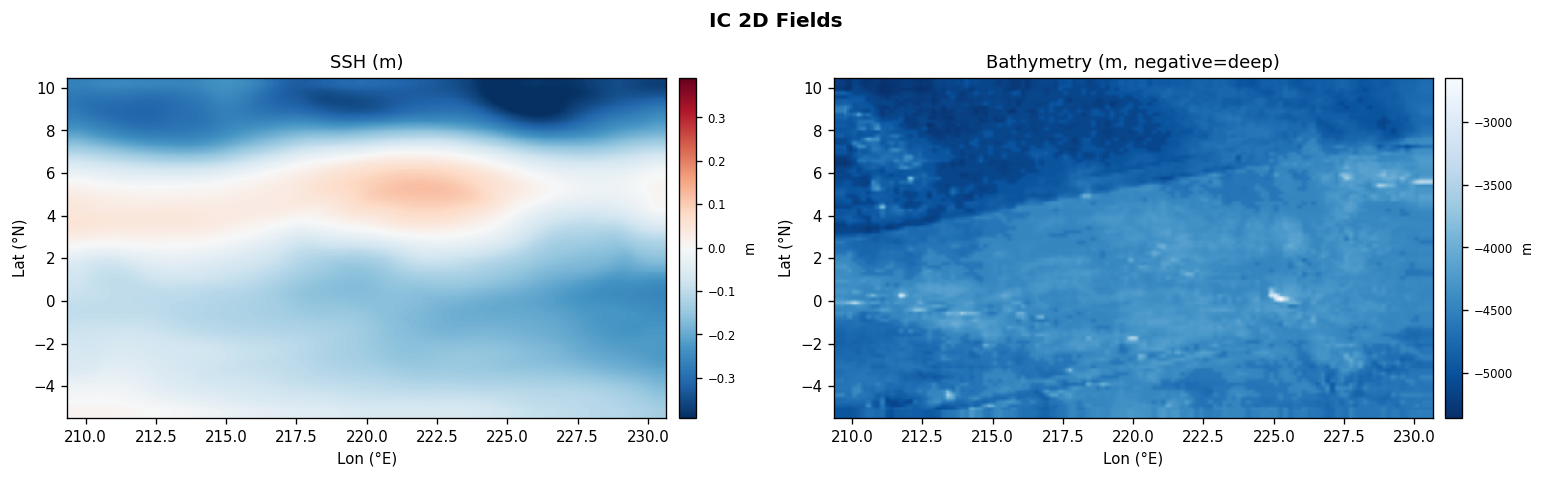

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if 'SSH' in ic:
    d = mask_land(ic['SSH'])
    vmin, vmax = sym_pct(d)
    im = map_ax(axes[0], d, title='SSH (m)', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    cbar(fig, axes[0], im, 'm')
else:
    axes[0].text(0.5, 0.5, 'SSH not found', ha='center', va='center', transform=axes[0].transAxes)

if 'Bathy' in ic:
    d = ic['Bathy'].copy().astype(float)
    d[d == 0] = np.nan   # land
    im = axes[1].pcolormesh(xc, yc, d, cmap='Blues_r', shading='auto', rasterized=True)
    axes[1].set(title='Bathymetry (m, negative=deep)', xlabel='Lon (°E)', ylabel='Lat (°N)')
    axes[1].set_xlim(xc[0], xc[-1]); axes[1].set_ylim(yc[0], yc[-1])
    cbar(fig, axes[1], im, 'm')
else:
    axes[1].text(0.5, 0.5, 'Bathy not found', ha='center', va='center', transform=axes[1].transAxes)

fig.suptitle('IC 2D Fields', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'ic_2d_fields.png'), dpi=150, bbox_inches='tight')
plt.show()

## Domain-Mean Vertical Profiles & T–S Diagram

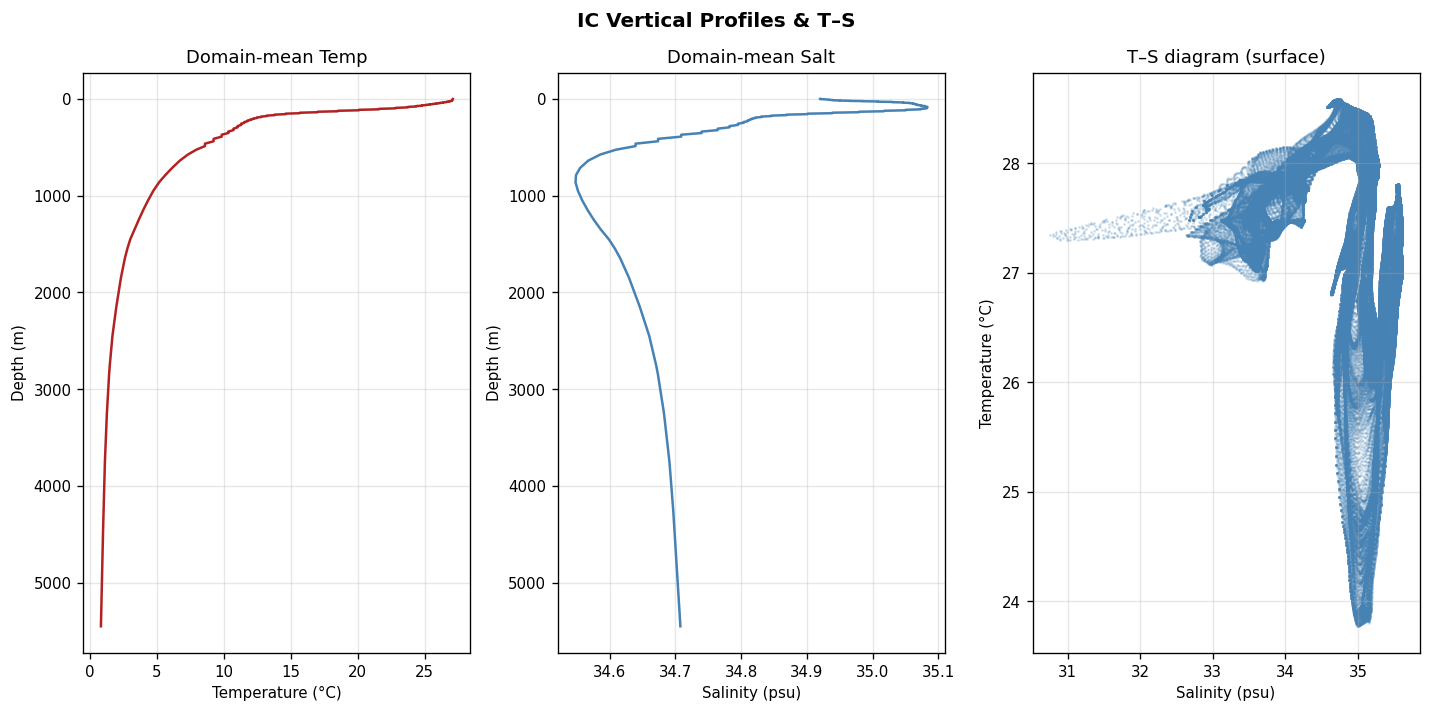

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for ax, (vname, label, color) in zip(
        axes[:2],
        [('Temp', 'Temperature (°C)', 'firebrick'),
         ('Salt', 'Salinity (psu)',    'steelblue')]):
    if vname not in ic:
        ax.text(0.5, 0.5, f'{vname} not loaded', ha='center', va='center',
                transform=ax.transAxes)
        continue
    arr = mask_land(ic[vname])
    profile = np.nanmean(arr, axis=(1, 2))   # [NZ]
    ax.plot(profile, RC, color=color, lw=1.5)
    ax.invert_yaxis()
    ax.set(xlabel=label, ylabel='Depth (m)', title=f'Domain-mean {vname}')
    ax.grid(True, alpha=0.3)

# T–S scatter at surface
ax = axes[2]
if 'Temp' in ic and 'Salt' in ic:
    T_surf = ic['Temp'][0, :, :].ravel().astype(float)
    S_surf = ic['Salt'][0, :, :].ravel().astype(float)
    mask   = (T_surf != 0) & (S_surf != 0) & np.isfinite(T_surf) & np.isfinite(S_surf)
    ax.scatter(S_surf[mask], T_surf[mask], s=0.5, alpha=0.2, color='steelblue', rasterized=True)
    ax.set(xlabel='Salinity (psu)', ylabel='Temperature (°C)', title='T–S diagram (surface)')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'T or S not loaded', ha='center', va='center', transform=ax.transAxes)

fig.suptitle('IC Vertical Profiles & T–S', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, 'ic_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()

---
# Boundary Conditions

## Load OBC files

In [14]:
# Boundary metadata: label → (npts, spatial coord array, x-axis label)
OBC_META = {
    'obcn': (NX, xc, 'Longitude (°E)', 'North OBC'),
    'obcs': (NX, xc, 'Longitude (°E)', 'South OBC'),
    'obcw': (NY, yc, 'Latitude (°N)',  'West OBC'),
    'obce': (NY, yc, 'Latitude (°N)',  'East OBC'),
}

def obc_fname(var, bnd):
    suffix = 'te' if var in ('T', 'S', 'U', 'V') else ''
    return f'{var}{bnd}_frmTP6Vel_EMv1{suffix}.bin' if var != 'Eta' else f'Eta{bnd}_frmTP6Vel_EMv1.bin'

obc = {}  # (bnd, var) → array
for bnd, (npts, coord, xlabel, title) in OBC_META.items():
    for var in ('T', 'S', 'U', 'V', 'Eta'):
        fname = obc_fname(var, bnd)
        path  = os.path.join(SETUP_DIR, fname)
        if not file_ok(path):
            continue
        print(f'Loading {fname} ...', end=' ')
        if var == 'Eta':
            obc[(bnd, var)] = load_obc_eta(path, npts)
        else:
            obc[(bnd, var)] = load_obc_3d(path, npts)
        print(obc[(bnd, var)].shape)

print(f'\nLoaded OBC keys: {sorted(obc.keys())}')

Loading Tobcn_frmTP6Vel_EMv1te.bin ... (122, 138, 512)
Loading Sobcn_frmTP6Vel_EMv1te.bin ... (122, 138, 512)
Loading Uobcn_frmTP6Vel_EMv1te.bin ... (122, 138, 512)
Loading Vobcn_frmTP6Vel_EMv1te.bin ... (122, 138, 512)
Loading Etaobcn_frmTP6Vel_EMv1.bin ... (122, 512)
Loading Tobcs_frmTP6Vel_EMv1te.bin ... (122, 138, 512)
Loading Sobcs_frmTP6Vel_EMv1te.bin ... (122, 138, 512)
Loading Uobcs_frmTP6Vel_EMv1te.bin ... (122, 138, 512)
Loading Vobcs_frmTP6Vel_EMv1te.bin ... (122, 138, 512)
Loading Etaobcs_frmTP6Vel_EMv1.bin ... (122, 512)
Loading Tobcw_frmTP6Vel_EMv1te.bin ... (122, 138, 384)
Loading Sobcw_frmTP6Vel_EMv1te.bin ... (122, 138, 384)
Loading Uobcw_frmTP6Vel_EMv1te.bin ... (122, 138, 384)
Loading Vobcw_frmTP6Vel_EMv1te.bin ... (122, 138, 384)
Loading Etaobcw_frmTP6Vel_EMv1.bin ... (122, 384)
Loading Tobce_frmTP6Vel_EMv1te.bin ... (122, 138, 384)
Loading Sobce_frmTP6Vel_EMv1te.bin ... (122, 138, 384)
Loading Uobce_frmTP6Vel_EMv1te.bin ... (122, 138, 384)
Loading Vobce_frmTP6Vel_E

## OBC Statistics

In [15]:
print(f'{"Boundary":6s}  {"Var":5s}  {"min":>10s}  {"max":>10s}  {"mean":>10s}  {"std":>10s}')
print('-' * 60)
for (bnd, var), arr in sorted(obc.items()):
    a = arr.ravel().astype(float)
    a = a[(a != 0.0) & np.isfinite(a)]
    if a.size == 0:
        continue
    print(f'{bnd:6s}  {var:5s}  {a.min():10.4g}  {a.max():10.4g}  '
          f'{a.mean():10.4g}  {a.std():10.4g}')

Boundary  Var           min         max        mean         std
------------------------------------------------------------
obce    Eta       -0.3354      0.1111    -0.07162     0.08896
obce    S            32.3       35.78       34.86      0.3296
obce    T           0.444       28.81       13.71       10.78
obce    U          -1.103       1.316    -0.02322      0.2269
obce    V         -0.5498      0.6707    0.003843     0.09012
obcn    Eta       -0.4896     -0.1566     -0.3358     0.07653
obcn    S           31.73       34.89       34.52      0.3293
obcn    T          0.8155        28.7       11.05       8.809
obcn    U         -0.8548      0.3913    -0.04436      0.1074
obcn    V         -0.4775      0.5999    0.005229     0.07737
obcs    Eta       -0.1773     0.06852    -0.05051     0.05118
obcs    S           34.53       35.84       35.07      0.4144
obcs    T          0.5132       28.12       14.18       10.78
obcs    U         -0.5512      0.1677     -0.0874      0.1025
obcs   

## OBC Depth Sections at t=6 h (upper 500 m)

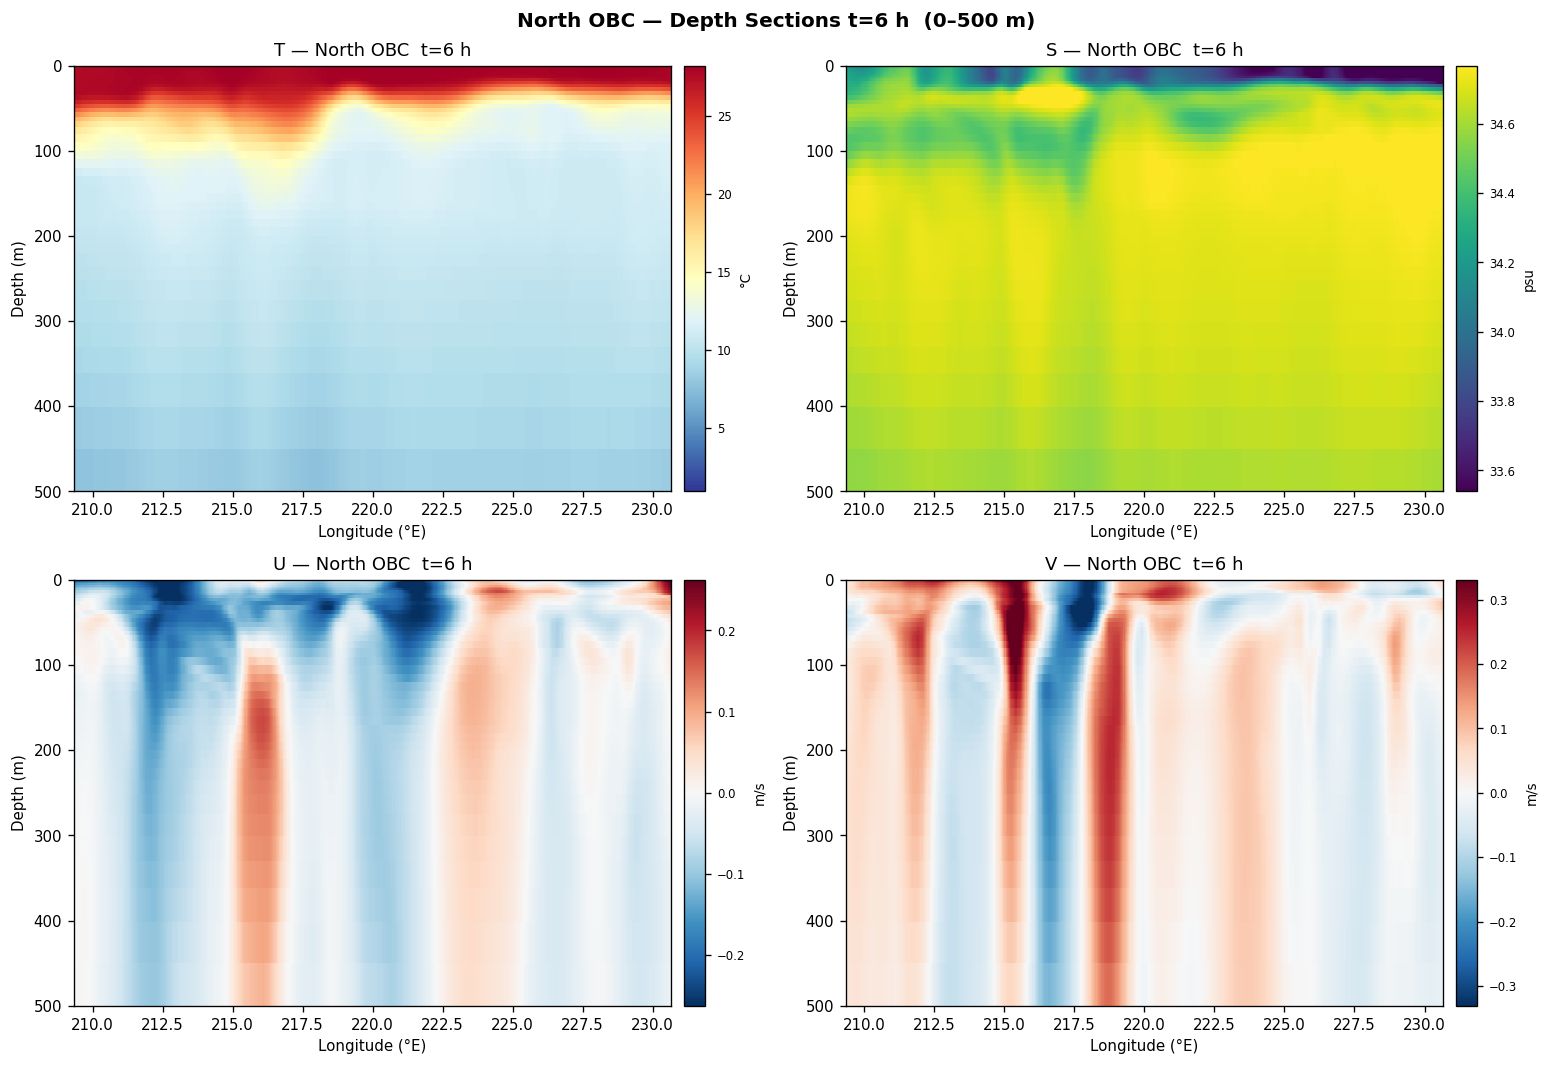

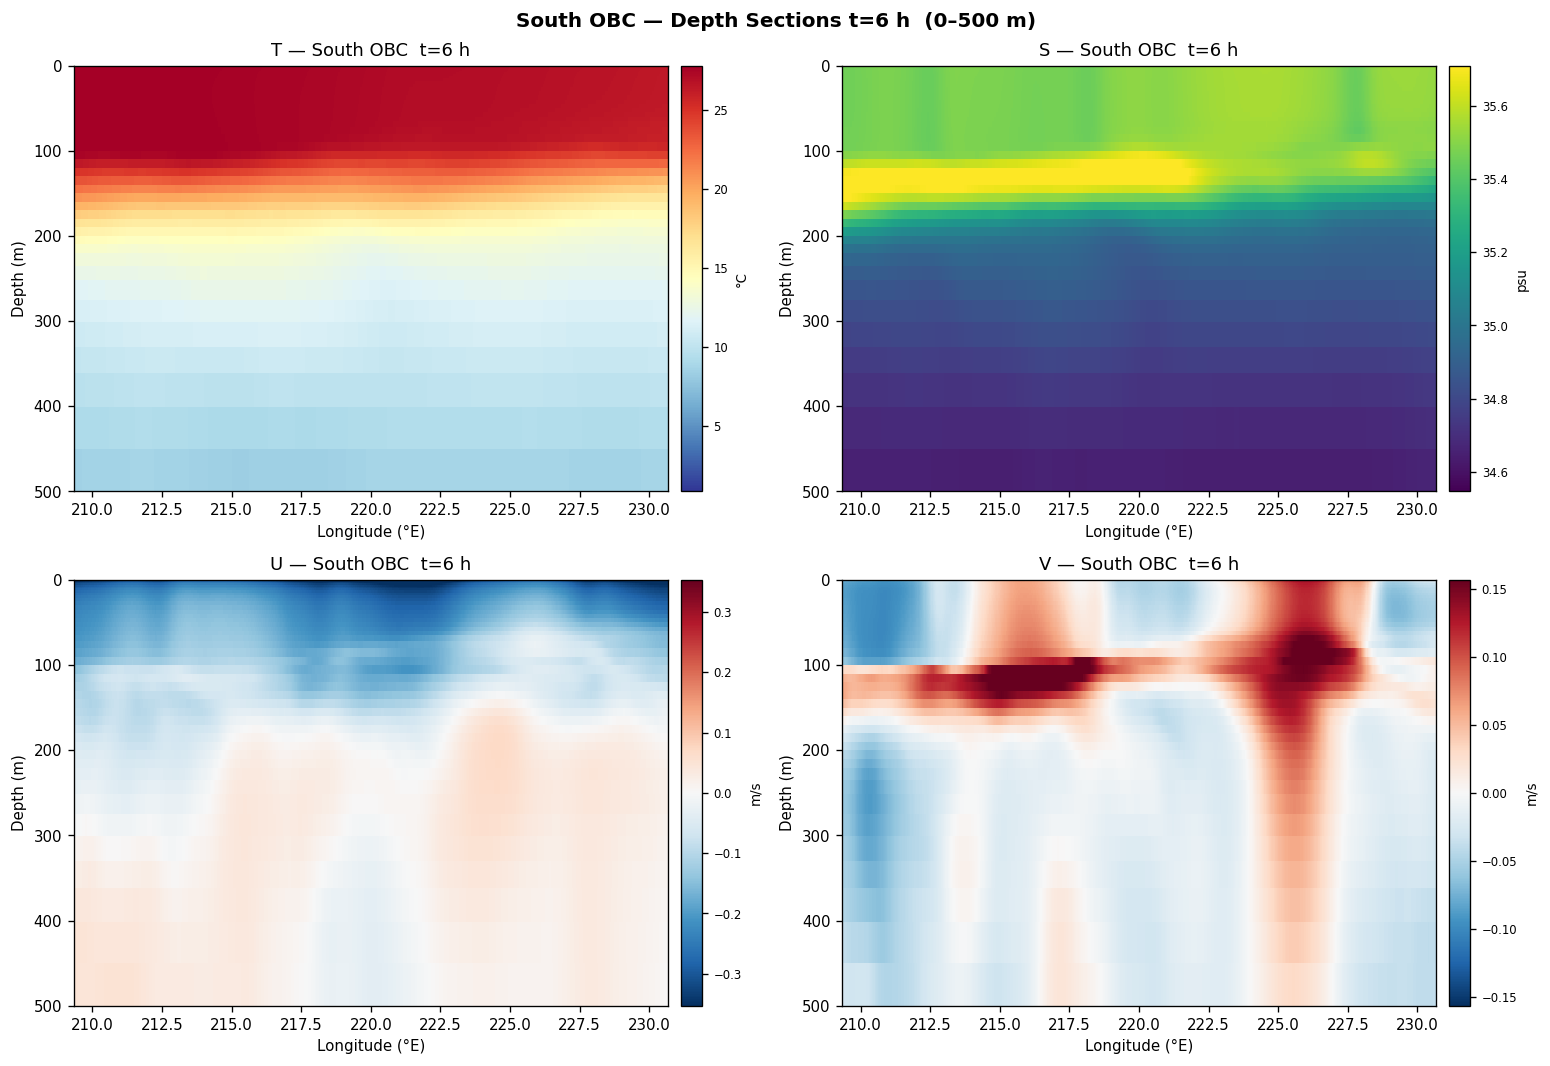

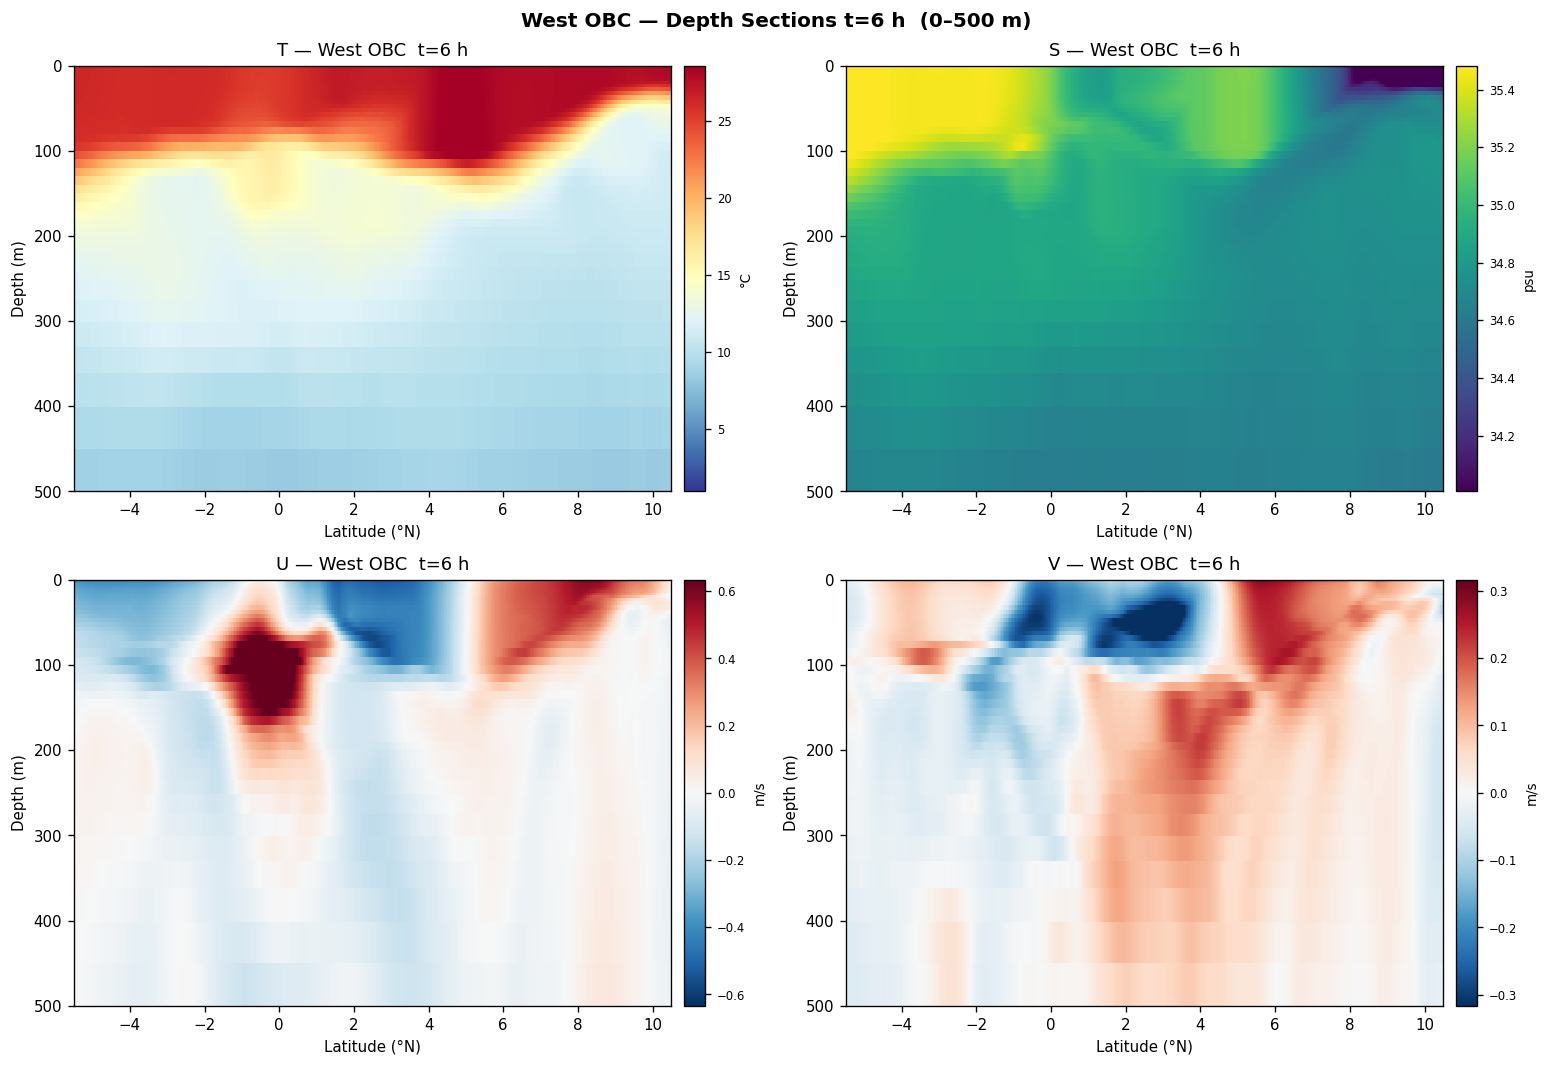

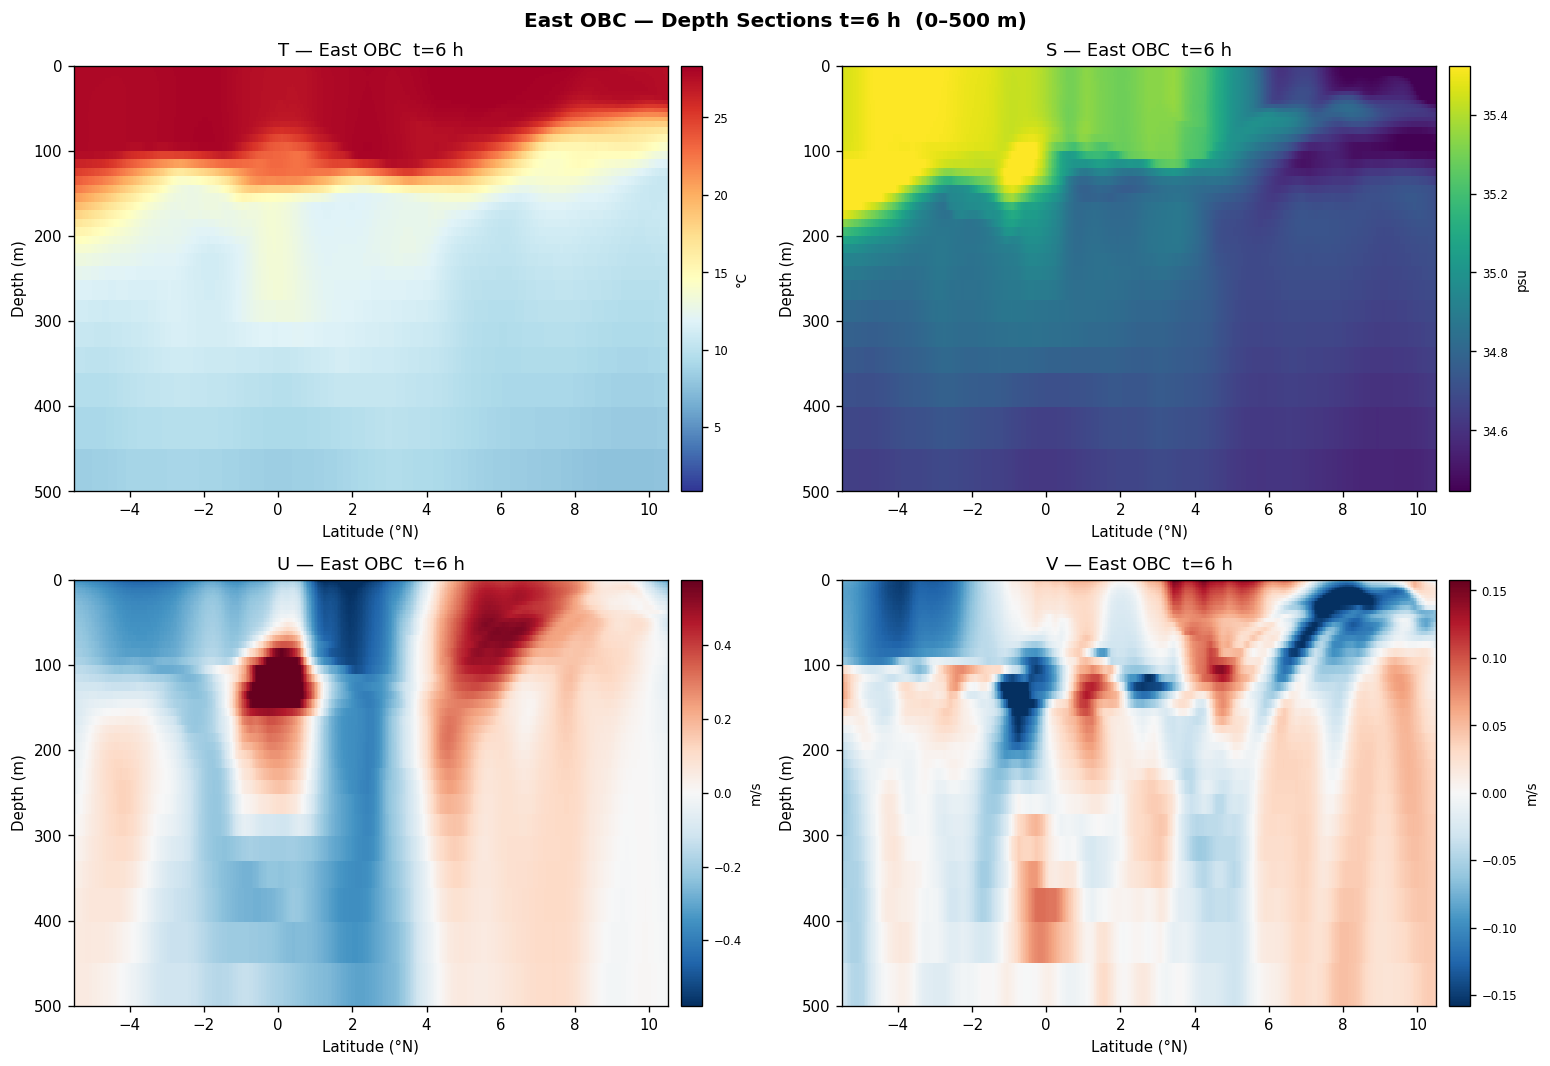

In [16]:
cfgs_obc = {'T': ('RdYlBu_r','°C'), 'S': ('viridis','psu'),
             'U': ('RdBu_r','m/s'), 'V': ('RdBu_r','m/s')}

for bnd, (npts, coord, xlabel, title) in OBC_META.items():
    avail = [v for v in ('T','S','U','V') if (bnd, v) in obc]
    if not avail:
        continue
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, var in zip(axes.ravel(), avail):
        sec = mask_land(obc[(bnd, var)][0, :, :])   # first time step [NZ, npts]
        cmap, label = cfgs_obc[var]
        vmin, vmax = sym_pct(sec) if var in ('U','V') else pct_range(sec)
        im = sec_ax(ax, sec, coord,
                    title=f'{var} — {title}  t=6 h',
                    cmap=cmap, vmin=vmin, vmax=vmax, xlabel=xlabel, zlim=(0, 500))
        cbar(fig, ax, im, label)
    for ax in axes.ravel()[len(avail):]:
        ax.set_visible(False)
    fig.suptitle(f'{title} — Depth Sections t=6 h  (0–500 m)', fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, f'obc_{bnd}_depsec_upper.png'), dpi=150, bbox_inches='tight')
    plt.show()

## OBC Depth Sections at t=6 h (full depth)

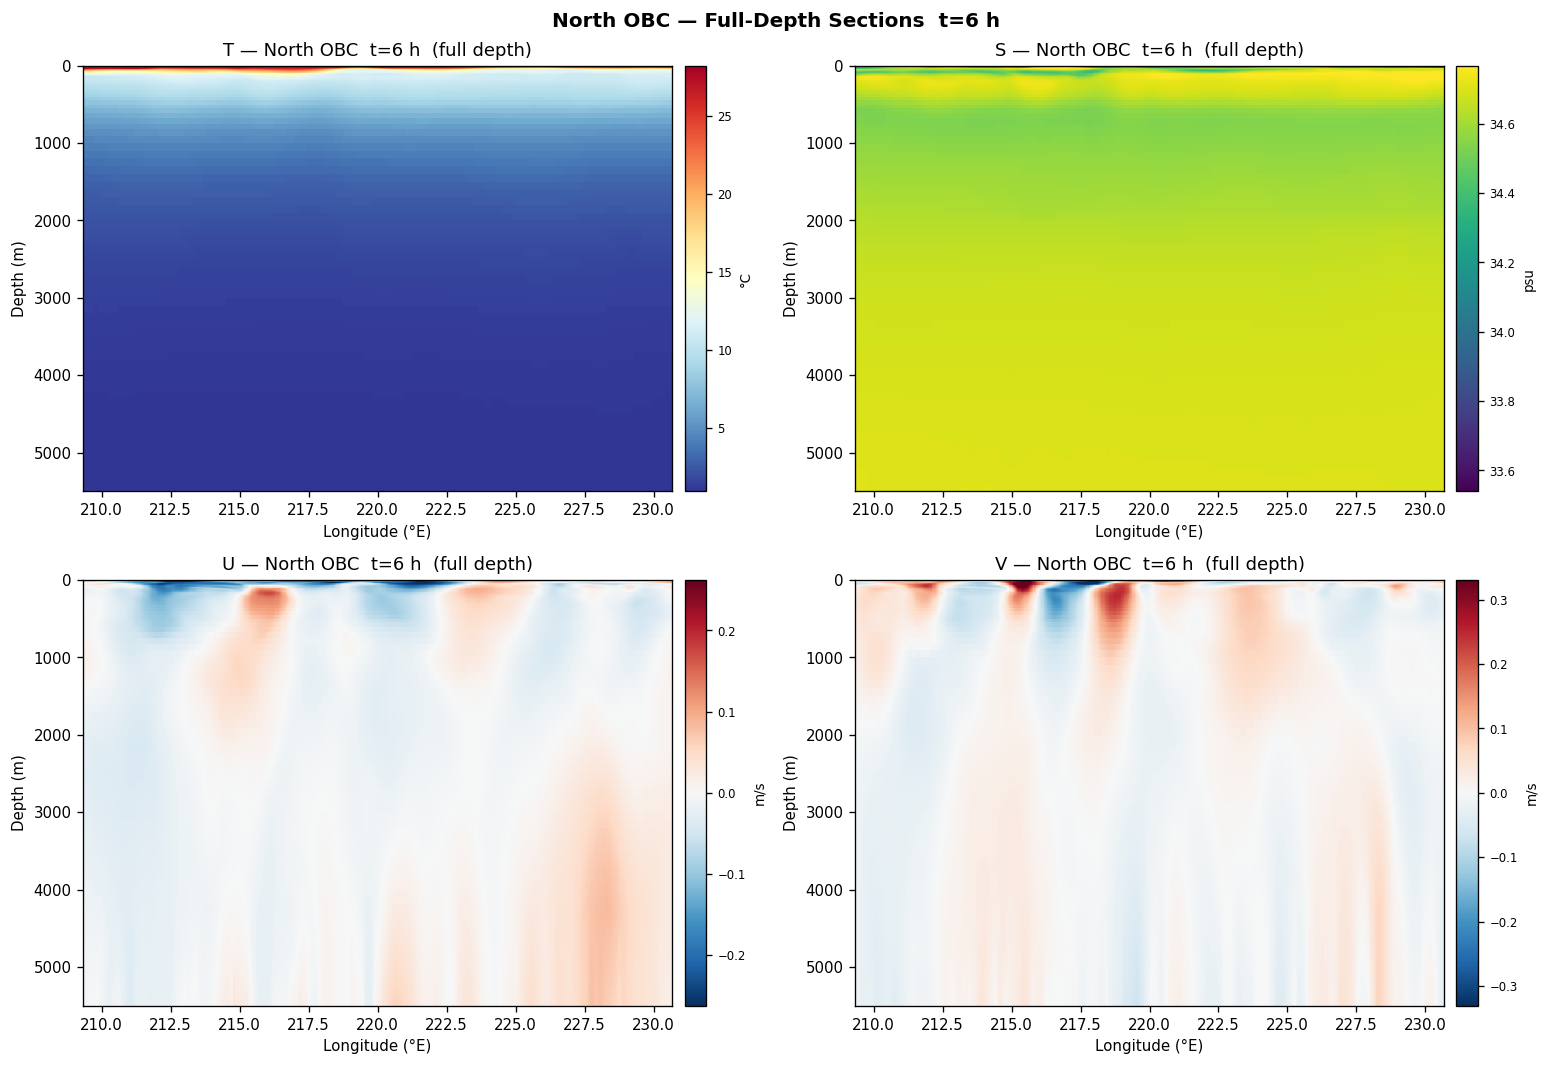

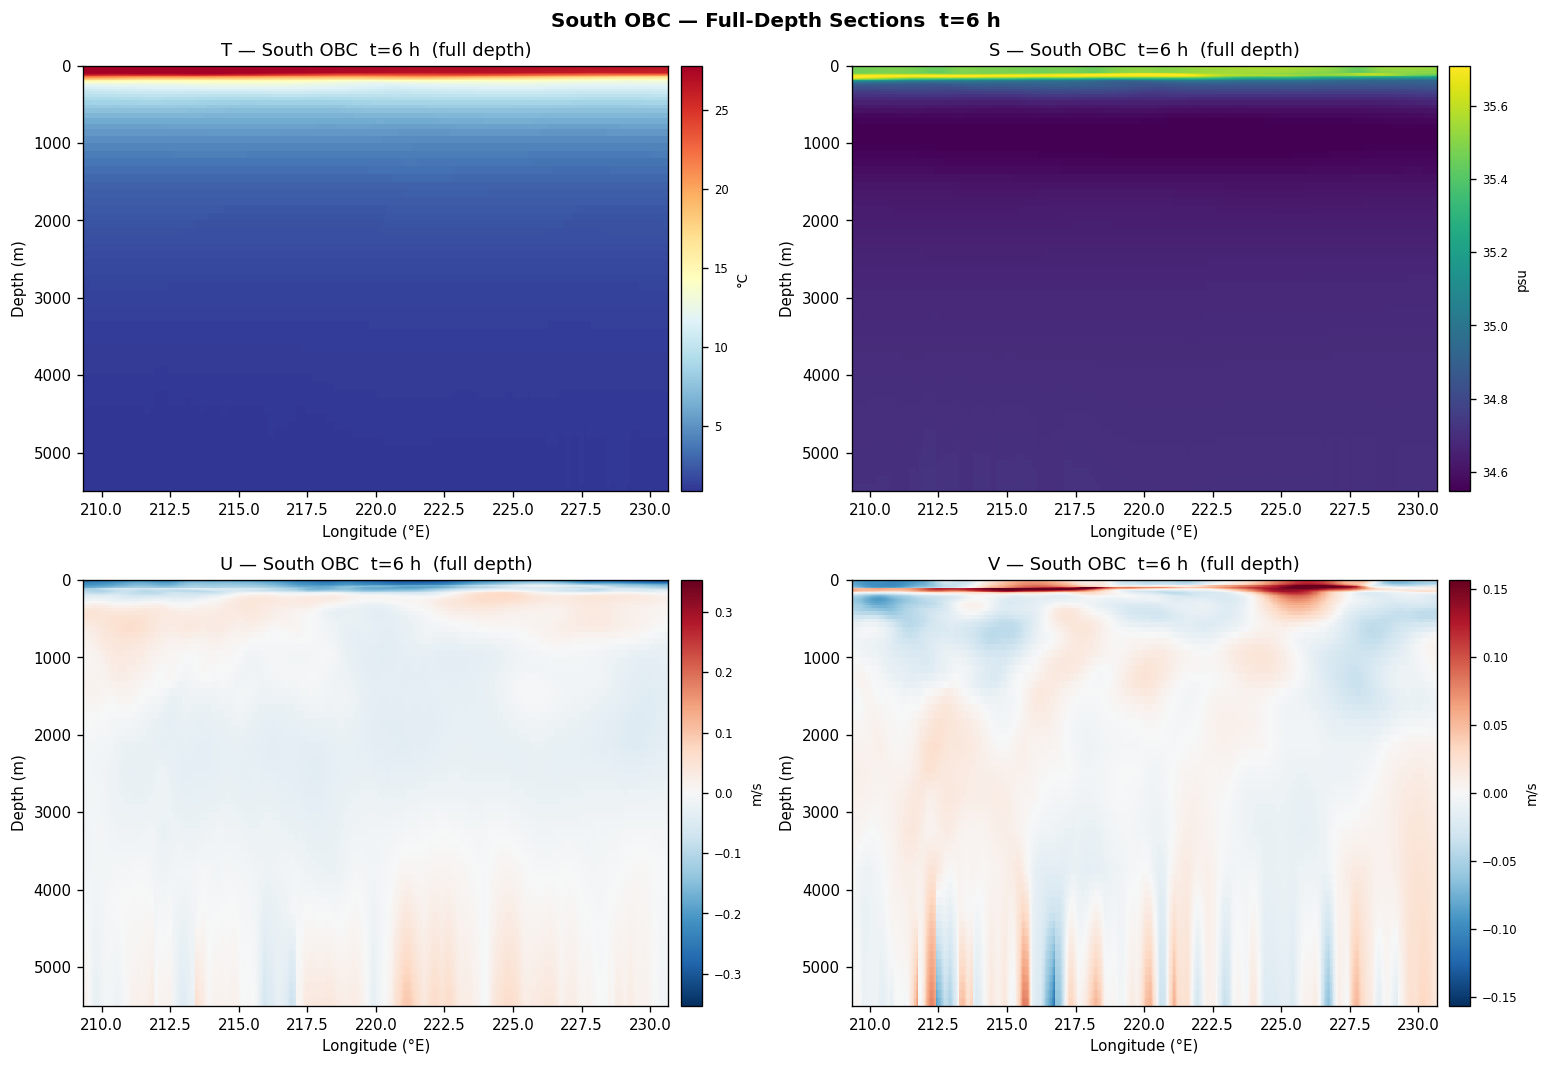

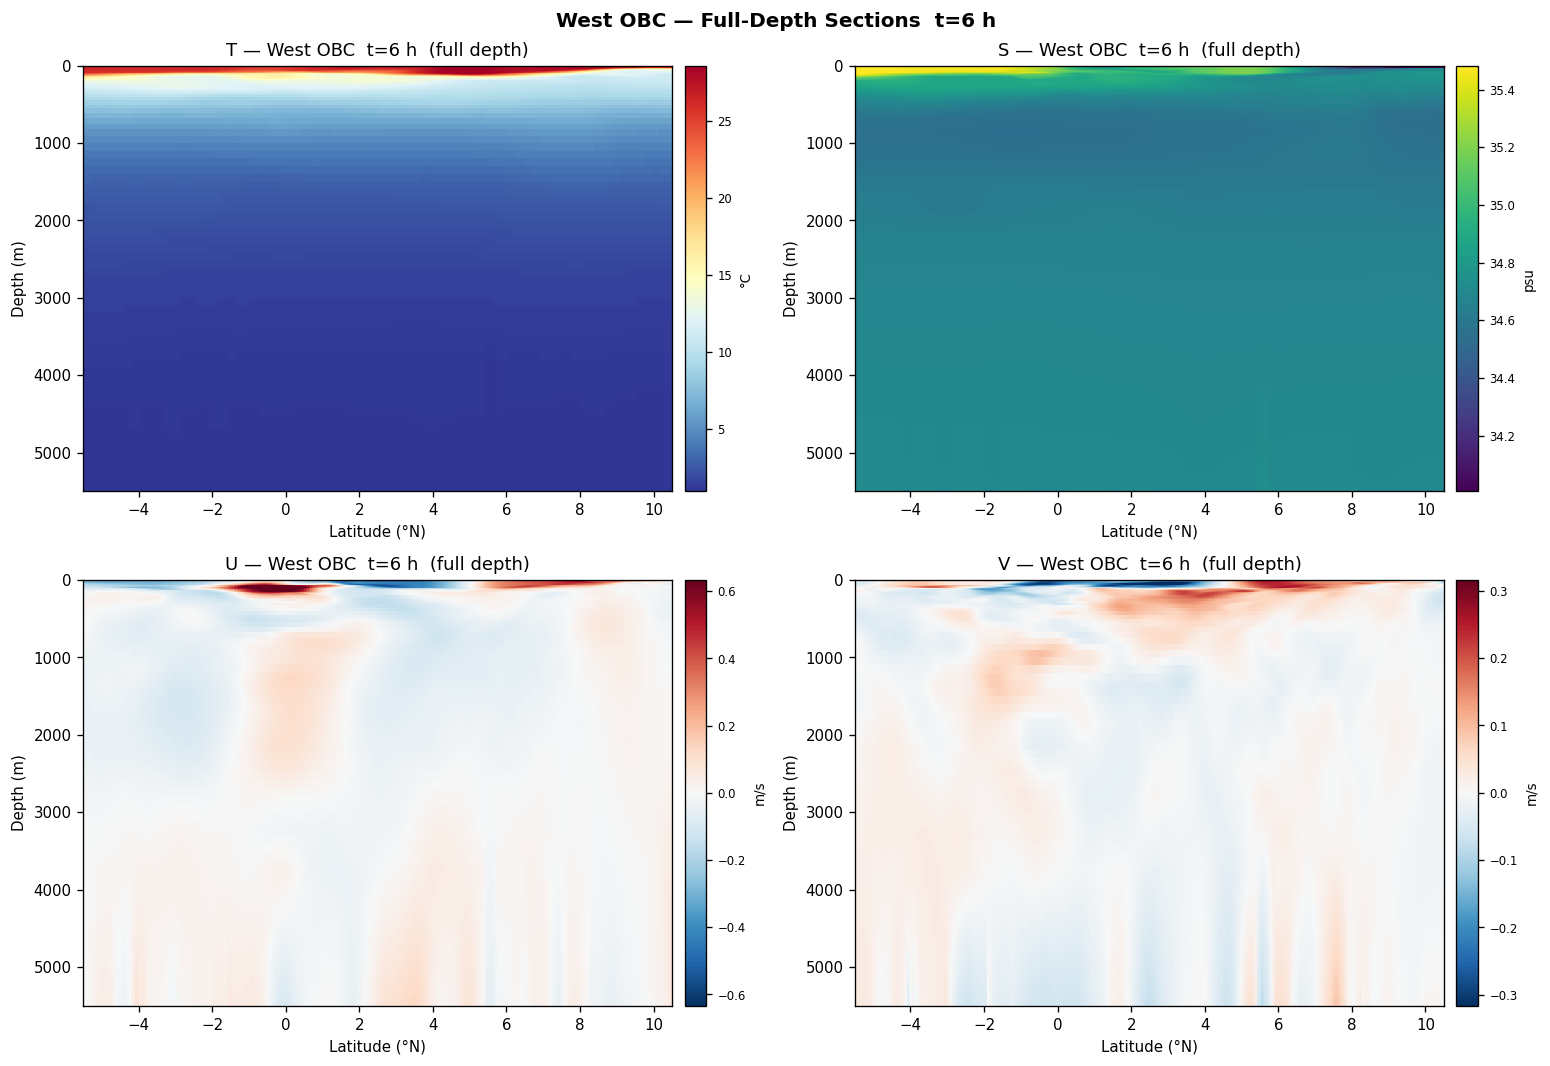

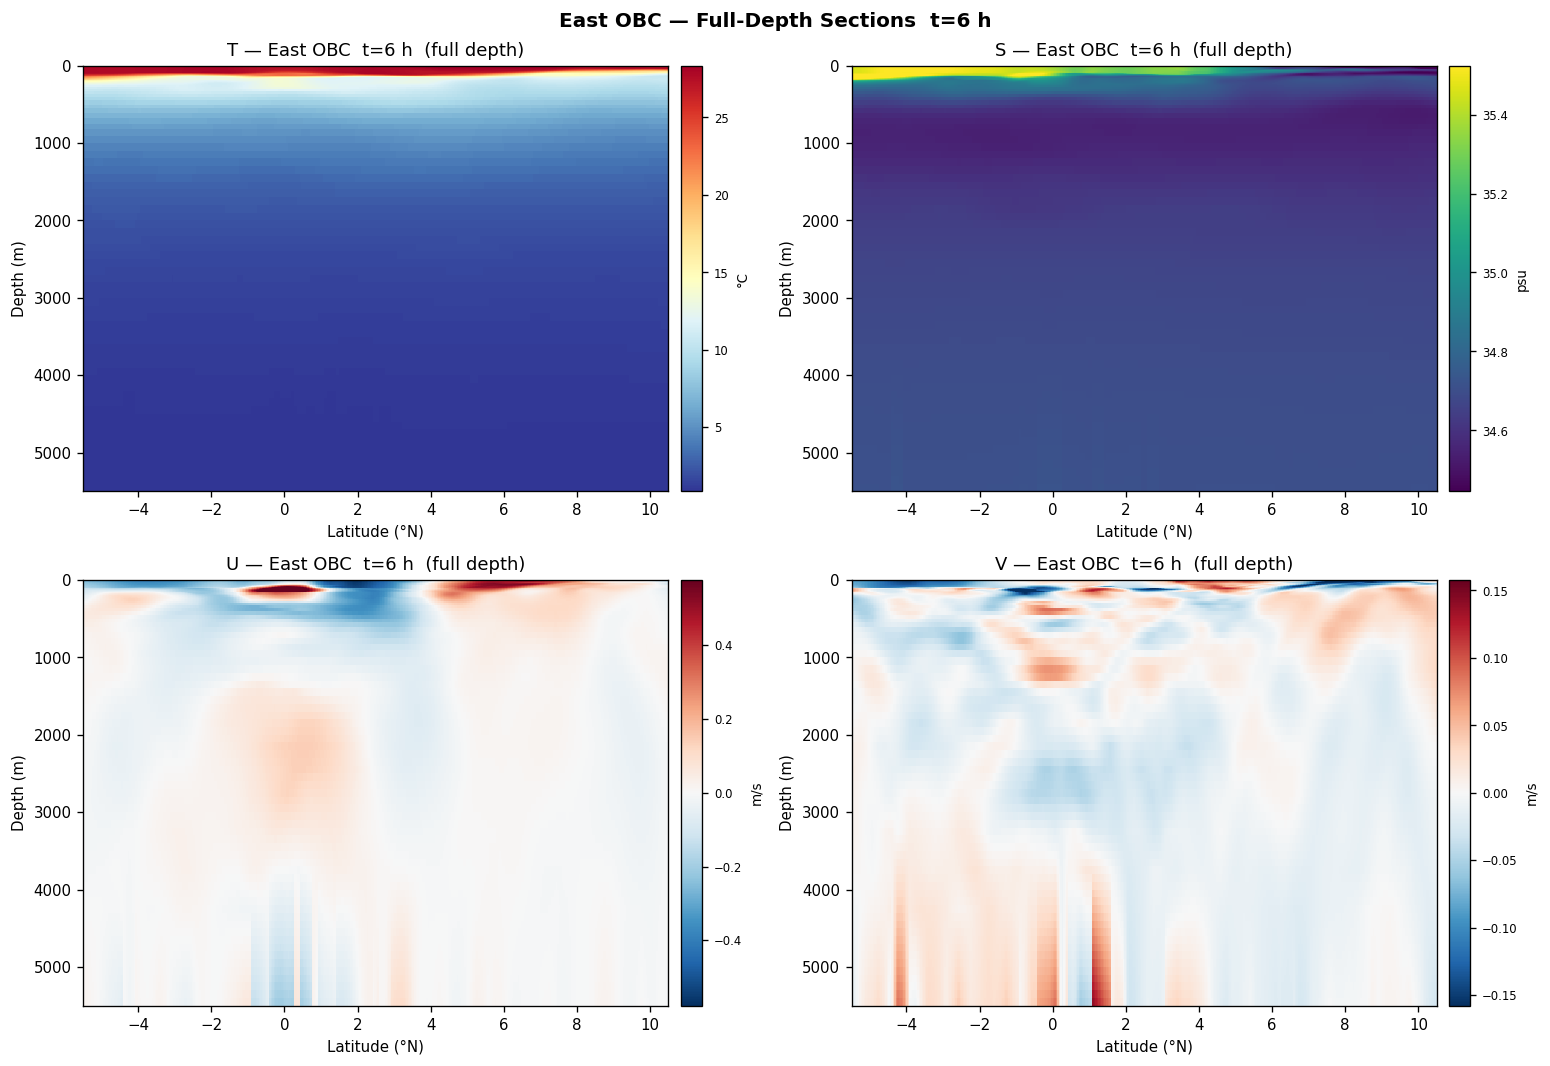

In [17]:
for bnd, (npts, coord, xlabel, title) in OBC_META.items():
    avail = [v for v in ('T','S','U','V') if (bnd, v) in obc]
    if not avail:
        continue
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, var in zip(axes.ravel(), avail):
        sec = mask_land(obc[(bnd, var)][0, :, :])
        cmap, label = cfgs_obc[var]
        vmin, vmax = sym_pct(sec) if var in ('U','V') else pct_range(sec)
        im = sec_ax(ax, sec, coord,
                    title=f'{var} — {title}  t=6 h  (full depth)',
                    cmap=cmap, vmin=vmin, vmax=vmax, xlabel=xlabel)
        cbar(fig, ax, im, label)
    for ax in axes.ravel()[len(avail):]:
        ax.set_visible(False)
    fig.suptitle(f'{title} — Full-Depth Sections  t=6 h', fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, f'obc_{bnd}_depsec_full.png'), dpi=150, bbox_inches='tight')
    plt.show()

## OBC Surface Hovmöllers  (T and cross-boundary velocity)

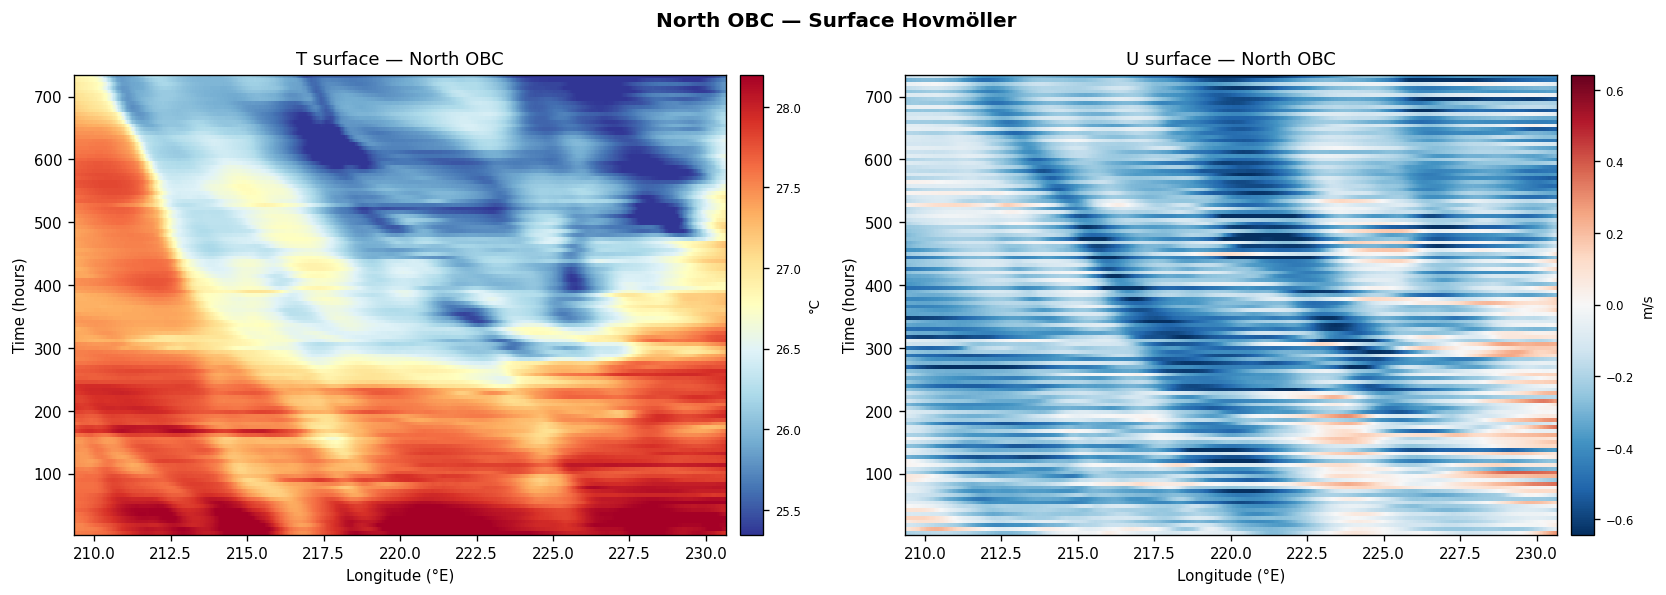

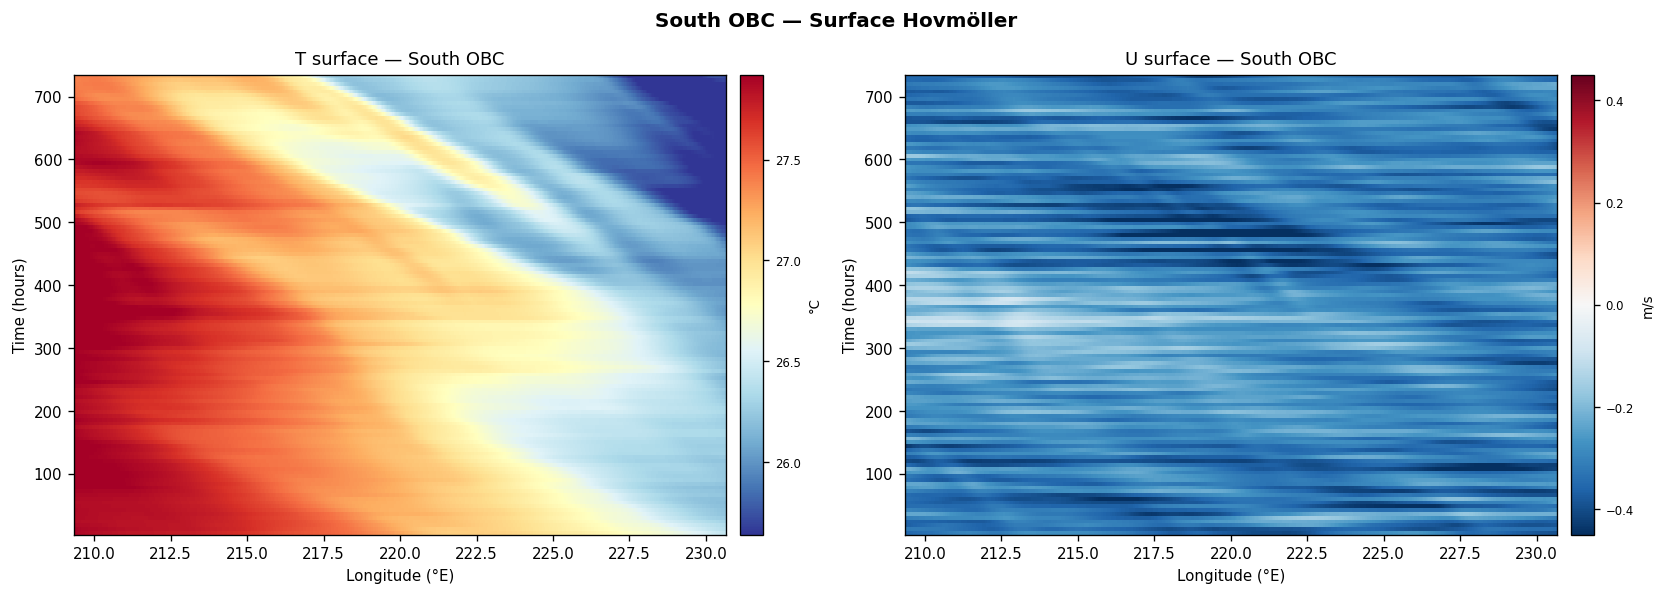

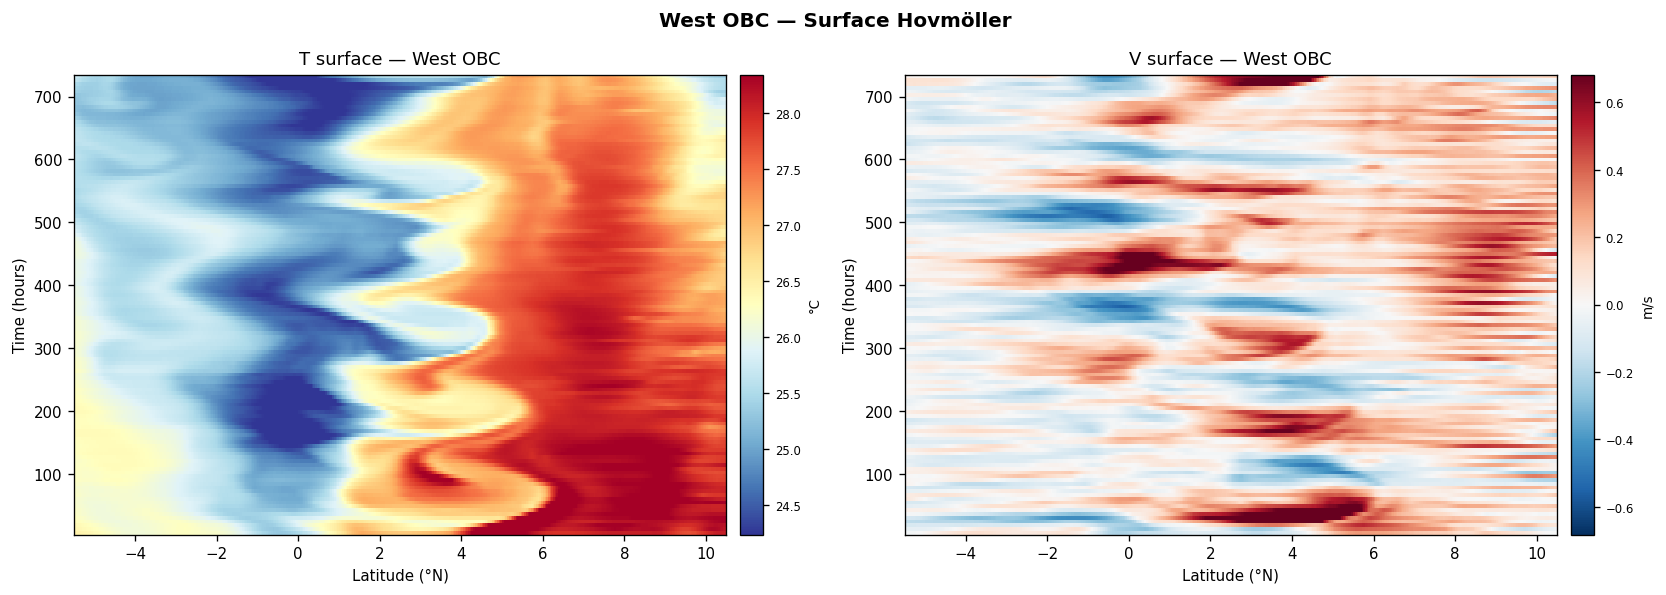

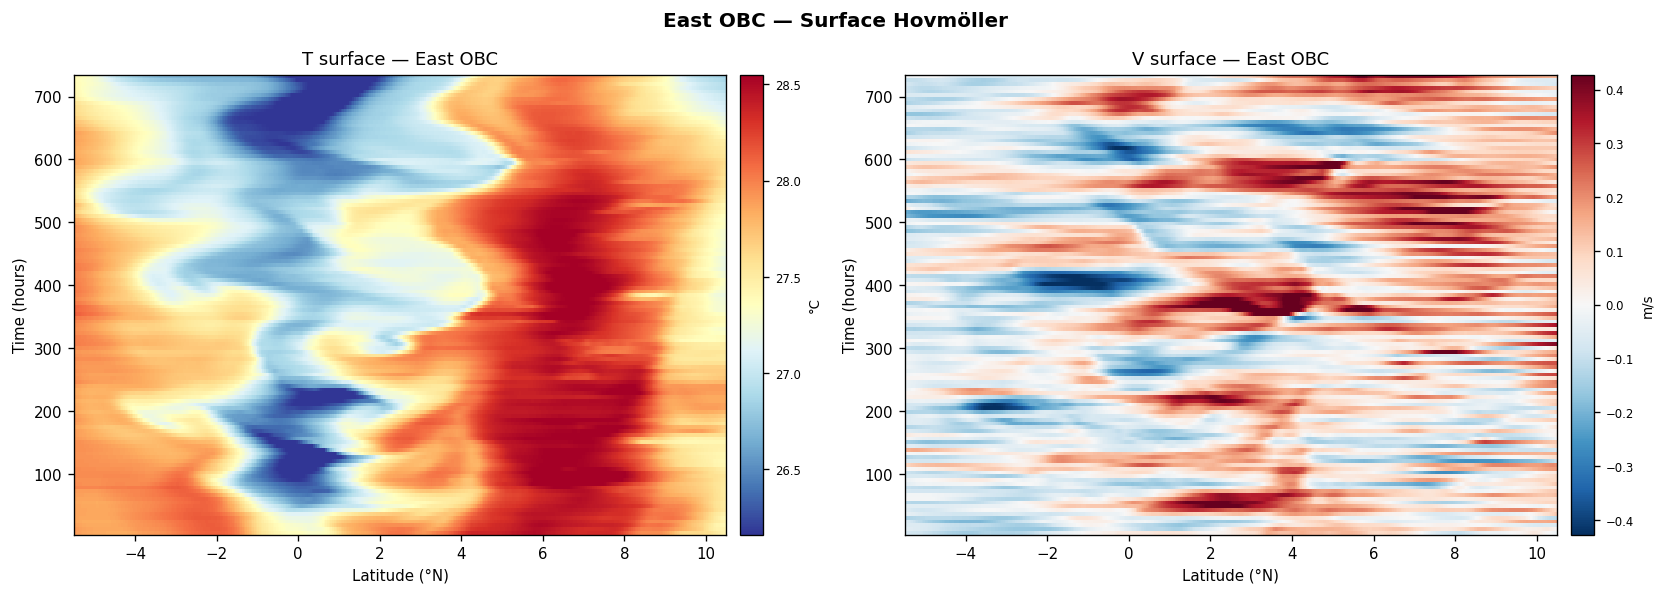

In [18]:
# Cross-boundary velocity: U for N/S, V for E/W
hov_vars_map = {'obcn': ['T','U'], 'obcs': ['T','U'],
                'obcw': ['T','V'], 'obce': ['T','V']}

for bnd, hvars in hov_vars_map.items():
    npts, coord, xlabel, title = OBC_META[bnd]
    avail = [v for v in hvars if (bnd, v) in obc]
    if not avail:
        continue
    fig, axes = plt.subplots(1, len(avail), figsize=(7 * len(avail), 5))
    if len(avail) == 1:
        axes = [axes]
    for ax, var in zip(axes, avail):
        surf = mask_land(obc[(bnd, var)][:, 0, :])   # surface [NTIME, npts]
        cmap, label = cfgs_obc[var]
        vmin, vmax = sym_pct(surf) if var in ('U','V') else pct_range(surf)
        im = ax.pcolormesh(coord, t_hours, surf, cmap=cmap, vmin=vmin, vmax=vmax,
                           shading='auto', rasterized=True)
        ax.set(xlabel=xlabel, ylabel='Time (hours)', title=f'{var} surface — {title}')
        cbar(fig, ax, im, label)
    fig.suptitle(f'{title} — Surface Hovmöller', fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, f'obc_{bnd}_hovmoller_surf.png'), dpi=150, bbox_inches='tight')
    plt.show()

## OBC Depth-Mean Hovmöllers

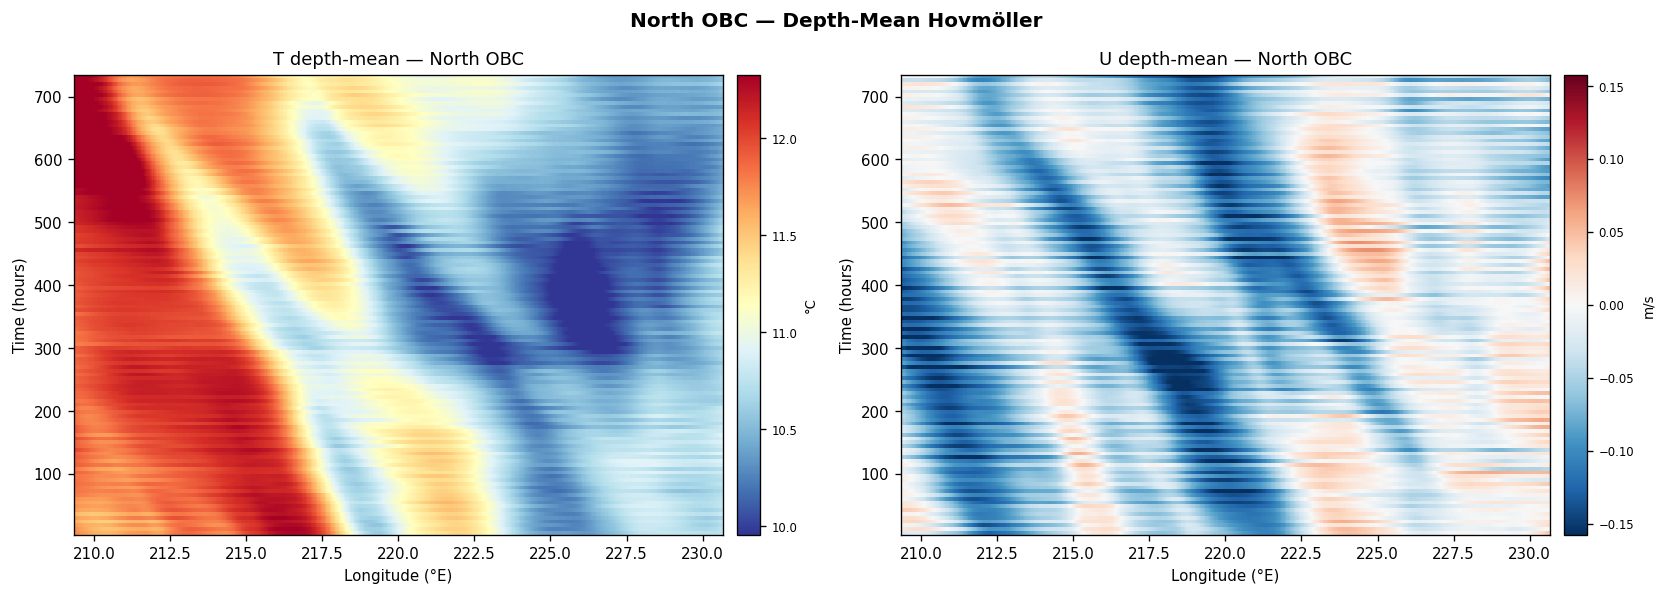

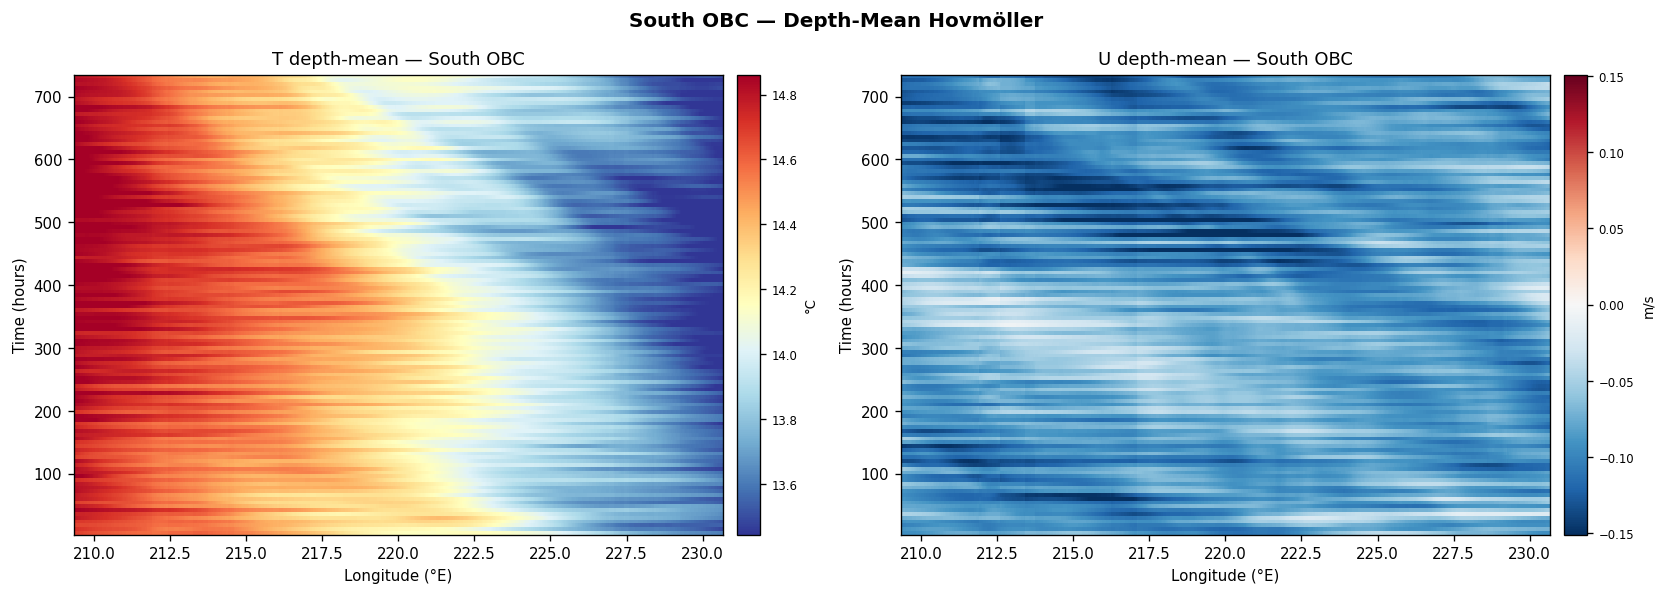

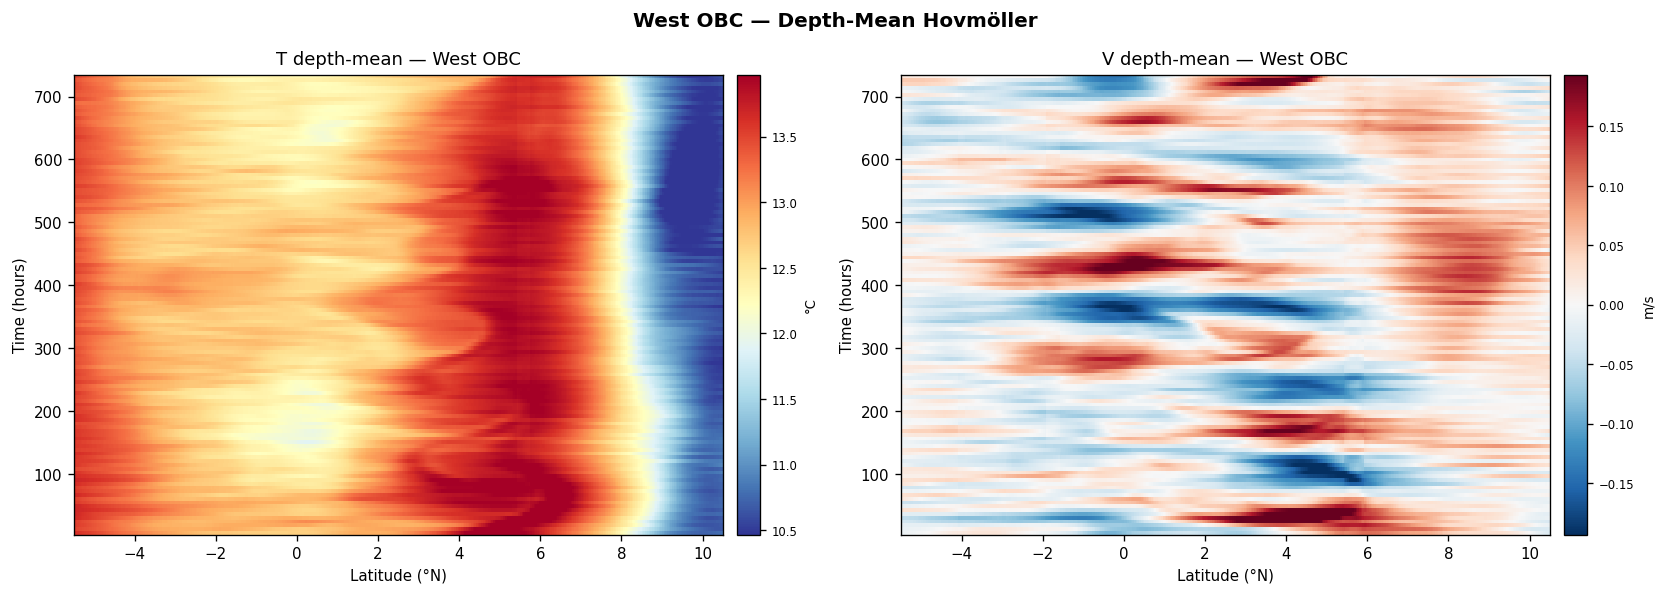

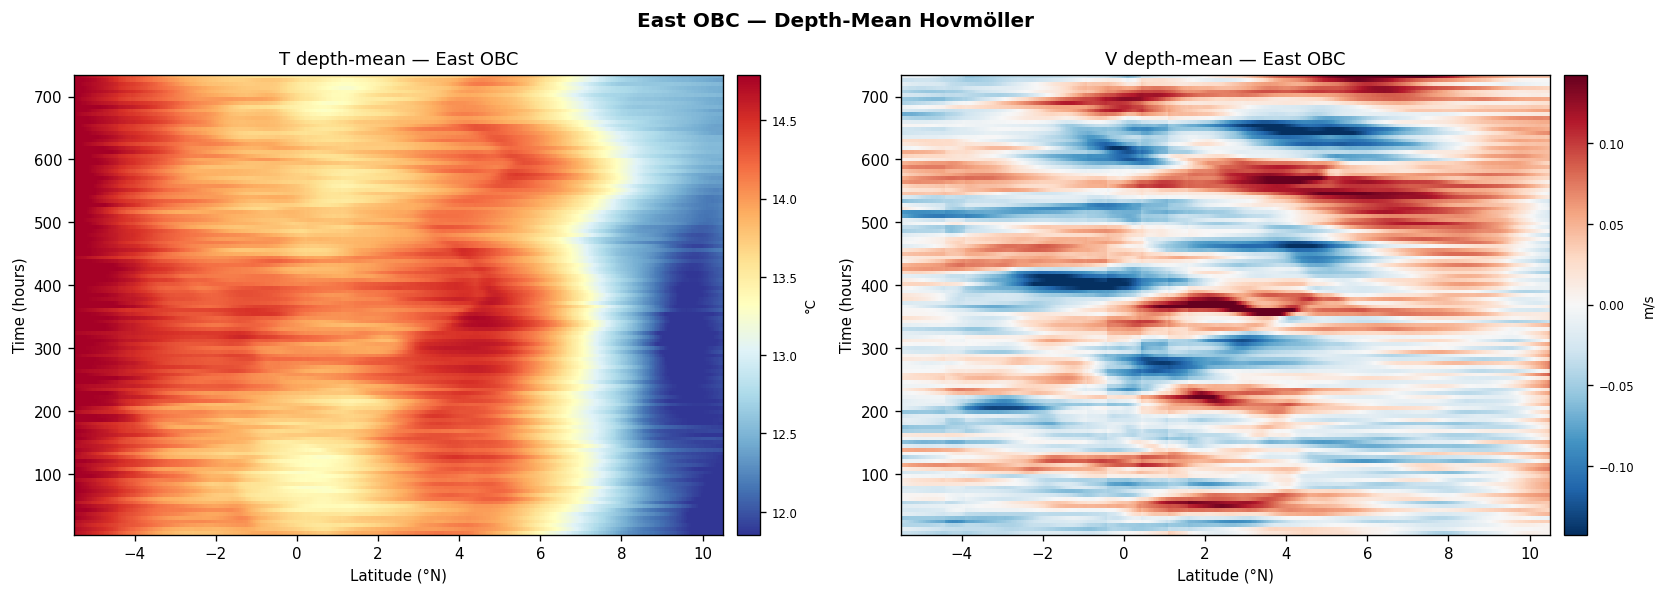

In [19]:
for bnd, hvars in hov_vars_map.items():
    npts, coord, xlabel, title = OBC_META[bnd]
    avail = [v for v in hvars if (bnd, v) in obc]
    if not avail:
        continue
    fig, axes = plt.subplots(1, len(avail), figsize=(7 * len(avail), 5))
    if len(avail) == 1:
        axes = [axes]
    for ax, var in zip(axes, avail):
        d = mask_land(obc[(bnd, var)])   # [NTIME, NZ, npts]
        dmean = np.nanmean(d, axis=1)   # depth mean [NTIME, npts]
        cmap, label = cfgs_obc[var]
        vmin, vmax = sym_pct(dmean) if var in ('U','V') else pct_range(dmean)
        im = ax.pcolormesh(coord, t_hours, dmean, cmap=cmap, vmin=vmin, vmax=vmax,
                           shading='auto', rasterized=True)
        ax.set(xlabel=xlabel, ylabel='Time (hours)', title=f'{var} depth-mean — {title}')
        cbar(fig, ax, im, label)
    fig.suptitle(f'{title} — Depth-Mean Hovmöller', fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, f'obc_{bnd}_hovmoller_depthmean.png'), dpi=150, bbox_inches='tight')
    plt.show()

## OBC SSH Hovmöller

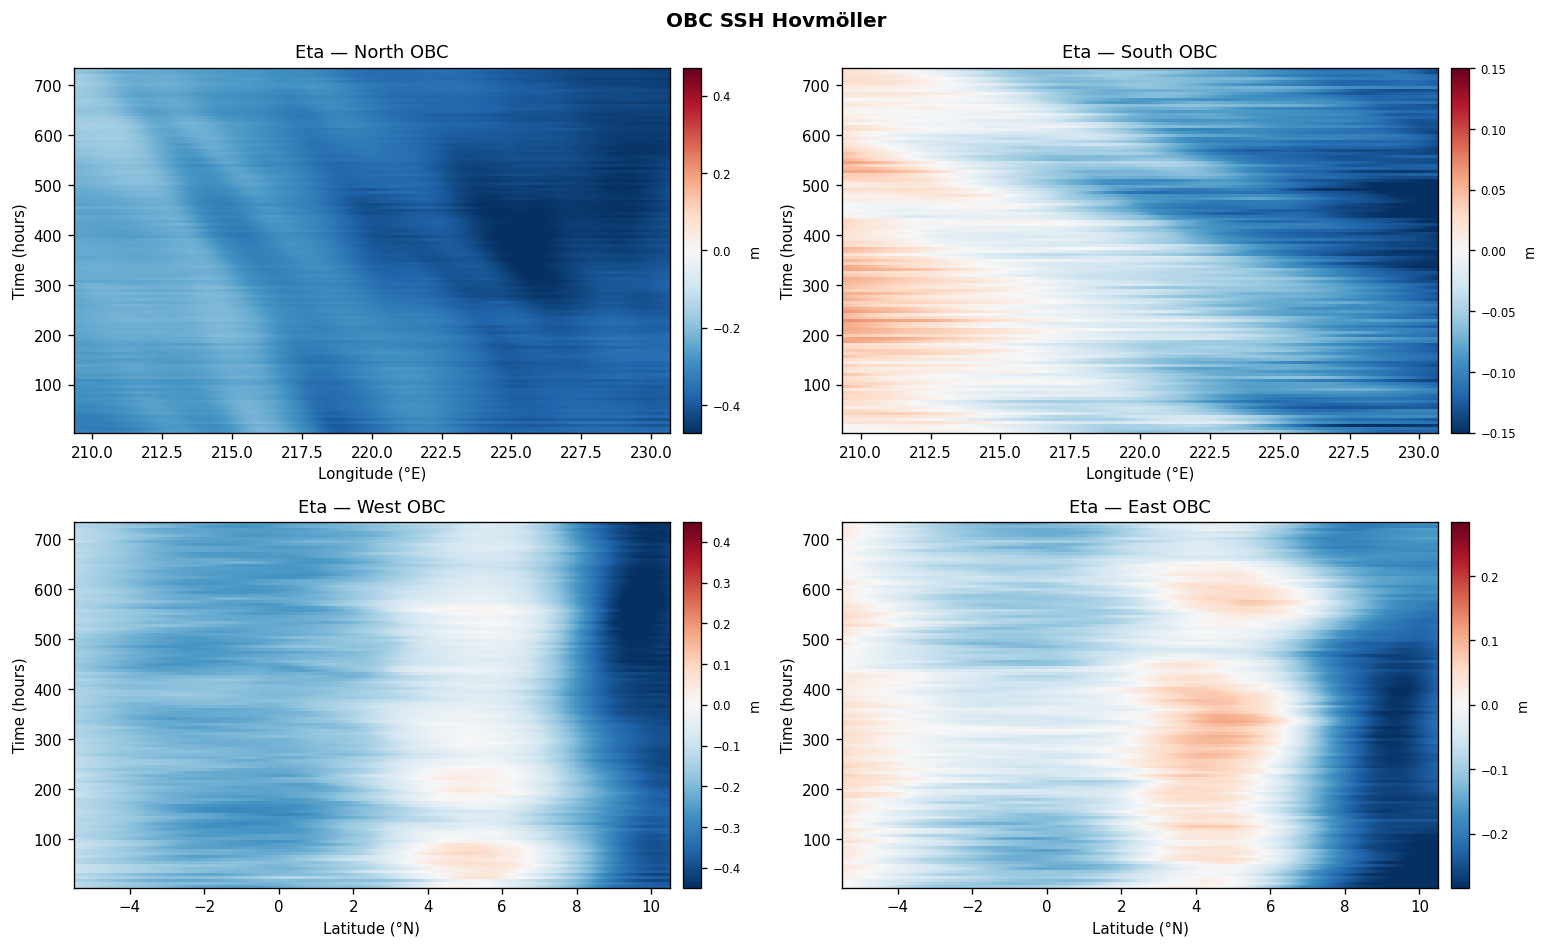

In [20]:
eta_bnds = [b for b in ('obcn','obcs','obcw','obce') if (b,'Eta') in obc]
if eta_bnds:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, bnd in zip(axes.ravel(), eta_bnds):
        npts, coord, xlabel, title = OBC_META[bnd]
        eta = mask_land(obc[(bnd,'Eta')])   # [NTIME, npts]
        vmin, vmax = sym_pct(eta)
        im = ax.pcolormesh(coord, t_hours, eta, cmap='RdBu_r', vmin=vmin, vmax=vmax,
                           shading='auto', rasterized=True)
        ax.set(xlabel=xlabel, ylabel='Time (hours)', title=f'Eta — {title}')
        cbar(fig, ax, im, 'm')
    for ax in axes.ravel()[len(eta_bnds):]:
        ax.set_visible(False)
    fig.suptitle('OBC SSH Hovmöller', fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, 'obc_eta_hovmoller.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No Eta OBC files loaded.')